In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [2]:
import seaborn as sns
from sklearn.metrics import auc

In [3]:
import mellon

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [5]:
# def prepare_for_boxplot_orig(enr,pop,seed,batch_sd,package,ds):
#     jobid = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-No"
#     jobid2 = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-Yes"
#     path = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_python/synthetic/'+ds+"/"+jobid+"/iteration_0"+'/'
#     path2 = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_python/synthetic/'+ds+"/"+jobid2+"/iteration_0"+'/'
#     index_col = np.array(pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+"mellon"+".csv",index_col = 0).index)
#     if package in[ "daseq" , "milo" , "cydar" , "louvain" ]:
#         package_performance = pd.read_csv(path+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv")
#         package_performance.index = index_col
#     elif package in ["meld"]:
#         batch_sd_processed = str(int(float(batch_sd)))
#         package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
#     elif package == "mellon":
#         batch_sd_processed = str(int(float(batch_sd)))
#         package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
#     return package_performance

In [149]:
def get_dm_benchmarking_results(enr,pop,seed,batch_sd,package,ds):
    #jobid = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-No"
    jobid2 = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-Yes-No"
    #path = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_with_aging_meld_beta/synthetic/'+ds+"/"+jobid+"/iteration_0"+'/'
    path2 = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_with_aging_dm_testing_0225/synthetic/'+ds+"/"+jobid2+"/iteration_0"+'/'
    index_col = np.array(pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+"mellon"+".csv",index_col = 0).index)
    if package in[ "daseq" , "milo" , "cydar" , "louvain" ]:
        package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv")
        package_performance.index = index_col
    # if package in ["mellon_high_ls","meld","cna","meld_default","mellon"]:
    #     batch_sd_processed = str(int(float(batch_sd)))
    #     package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
    if package in ["meld","cna","meld_default"]:
        batch_sd_processed = str(int(float(batch_sd)))
        package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
    if package in ["mellon","mellon_high_ls"]:
        batch_sd_processed = str(int(float(batch_sd)))
        package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col= 0)
        #package_performance = pd.read_csv(path2+"mellon_zscore.csv",index_col = 0)
        
    return package_performance

In [138]:
def find_ground_truth(enr,pop,seed,ds):
    # job id has to match with the path where the ground truth saved
    jobid = ds+"-"+pop+"-"+enr+"-"+seed+"-"+"0"+"-No-mellon_pca-DM"
    path = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/'+ds+"/"+jobid+"/iteration_0"+'/'
    package_coldata = pd.read_csv(path+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+".coldata.csv")
    true_labels_df  = pd.DataFrame(package_coldata["true_labels"],index = package_coldata.index)
    condition1_prob = pd.DataFrame(package_coldata["Condition1_prob"],index = package_coldata.index)
    condition2_prob = pd.DataFrame(package_coldata["Condition2_prob"],index = package_coldata.index)
    synth_labels = pd.DataFrame(package_coldata["synth_labels"],index = package_coldata.index)
    final_df = pd.DataFrame()
    for i in [true_labels_df,condition1_prob,condition2_prob,synth_labels]:
        final_df = pd.concat([final_df,i],axis = 1)
    lfc_truth = np.log(final_df["Condition2_prob"]) - np.log(final_df["Condition1_prob"])
    # scaler = StandardScaler()
    # lfc_truth = lfc_truth.values.reshape(-1,1)
    #                             # Fit the scaler on the data and transform the data
    # lfc_truth = scaler.fit_transform(lfc_truth)
    final_df["lfc_truth"] = lfc_truth
    return final_df

In [23]:
from sklearn.preprocessing import StandardScaler

In [140]:
def get_results(ds):
    performance_dict = {}
    ground_truth_dict = {}
    

    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
    
    #,"0.75","1","1.25","1.5"
        ## no batch effect added in this case
    for i in ["0"]:
        for j in ["43","44","45"]:
                for k in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        result_df = pd.DataFrame()
                        #for m in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
                        for m in ["meld","mellon","cna","meld_default","mellon_high_ls"]:
                            if m == "meld":
                                performance_package = get_dm_benchmarking_results(k,w,j,i,m,ds)
                                #performance_package =performance_package.reshape(1, -1)
                                first_column = performance_package.iloc[:, 0]
                                #first_column = first_column.rename(m)
                                lfc_sample = np.log(np.array(first_column.values)) - np.log(1 - np.array(first_column.values))
                                                                # Initialize the scaler
                                # scaler = StandardScaler()
                                # lfc_sample = lfc_sample.reshape(-1,1)
                                # # Fit the scaler on the data and transform the data
                                # lfc_sample = scaler.fit_transform(lfc_sample)
        
                                lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
                                #lfc_sample_df = lfc_sample_df.rename(m)
                                result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            elif m == "meld_default":
                                    performance_package = get_dm_benchmarking_results(k,w,j,i,m,ds)
                                    #performance_package =performance_package.reshape(1, -1)
                                    first_column = performance_package.iloc[:, 0]
                                    #first_column = first_column.rename(m)
                                    lfc_sample = np.log(np.array(first_column.values)) - np.log(1 - np.array(first_column.values))
                                                                    # Initialize the scaler
                                    # scaler = StandardScaler()
                                    # lfc_sample = lfc_sample.reshape(-1,1)
                                    # # Fit the scaler on the data and transform the data
                                    # lfc_sample = scaler.fit_transform(lfc_sample)

                                    lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])

                                    #lfc_sample_df = lfc_sample_df.rename(m)
                                    result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            elif m == "cydar":
                                performance_package = get_dm_benchmarking_results(k,w,j,i,m,ds)
                                #performance_package =performance_package.reshape(1, -1)
                                first_column = performance_package.iloc[:, 0]
                                #first_column = first_column.rename(m)
                                lfc_sample = np.array(first_column.values)
                                lfc_sample = lfc_sample.reshape(-1,1)
                                # Initialize the scaler
                                scaler = StandardScaler()

                                # Fit the scaler on the data and transform the data
                                lfc_sample = scaler.fit_transform(lfc_sample)
                                lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
                                #lfc_sample_df = lfc_sample_df.rename(m)
                                result_df = pd.concat([result_df, lfc_sample_df], axis=1)
#                             elif m == "mellon":
#                                 performance_package = prepare_for_boxplot_orig(k,w,j,i,m,ds)
#                                 #performance_package =performance_package.reshape(1, -1)
#                                 first_column = performance_package.iloc[:, 0]
#                                 #first_column = first_column.rename(m)
#                                 lfc_sample = np.array(first_column.values)
#                                 lfc_sample = lfc_sample.reshape(-1,1)
#                                 # Initialize the scaler
#                                 scaler = StandardScaler()

#                                 # Fit the scaler on the data and transform the data
#                                 lfc_sample = scaler.fit_transform(lfc_sample)
#                                 lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
#                                 #lfc_sample_df = lfc_sample_df.rename(m)
#                                 result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            else:
                                performance_package = get_dm_benchmarking_results(k,w,j,i,m,ds)

                                first_column = performance_package.iloc[:, 0]  # Get the first column of the current DataFrame
                                first_column = first_column.rename(m)
                                lfc_sample_df = pd.DataFrame(first_column,index =performance_package.index )
                                result_df = pd.concat([result_df,lfc_sample_df],axis=1)
                        performance_dict[i+"_"+j+"_"+w+"_"+k] = result_df
                        ground_truth_i = find_ground_truth(k,w,j,ds)
                        ground_truth_i.index = result_df.index
                        ground_truth_dict[i+"_"+j+"_"+w+"_"+k] = ground_truth_i
                        
    return performance_dict,ground_truth_dict

In [26]:
performance_dict,ground_truth_dict = get_results("branch")

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score


In [28]:
def modify_ground_truth_direction(ground_truth_df):
    da_ground_truth = []
    for i in list(ground_truth_df["true_labels"].values):
        if i == "NegLFC":
            i = "DA"
        elif i == "PosLFC":
            i = "DA"
        else:
            i = i
        da_ground_truth.append(i)
    ground_truth_df["da_ground_truth"] = da_ground_truth
    return ground_truth_df

In [201]:
def modified_auroc(ground_truth_df, result_df,package):
    ground_truth_df = modify_ground_truth_direction(ground_truth_df)
    true_label = ground_truth_df["true_labels"]
    true_label_da = ground_truth_df["da_ground_truth"]
    
    true_label_da_true = (true_label_da == "DA")
    true_label_transformed_neg = (true_label == "NegLFC")
    true_label_transformed_pos = (true_label == "PosLFC")
    
    lfc = result_df[package]
    if np.any(true_label_da_true) and np.any(~true_label_da_true):
        auc_score_da = roc_auc_score(true_label_da_true, np.abs(lfc))
        # if auc_score_neg <= 0.5:
        #     auc_score_neg = 1 - auc_score_neg
    else:
        auc_score_da = np.nan

    if np.any(true_label_transformed_neg) and np.any(~true_label_transformed_neg):
        auc_score_neg = roc_auc_score(true_label_transformed_neg, -lfc)
        # if auc_score_pos <= 0.5:
        #     auc_score_pos = 1 - auc_score_pos
    else:
        auc_score_neg = np.nan
    # except ValueError as e:
    #     print(f"ValueError: {e}")
    #     auc_score_neg = np.nan
    #     auc_score_pos = np.nan
    
    if np.any(true_label_transformed_pos) and np.any(~true_label_transformed_pos):
        auc_score_pos = roc_auc_score(true_label_transformed_pos, lfc)
        # if auc_score_pos <= 0.5:
        #     auc_score_pos = 1 - auc_score_pos
    else:
        auc_score_pos = np.nan
    
    auc_score = np.nanmean([auc_score_neg, auc_score_pos])
    auc_dict = {"mean_auroc":auc_score,
                "da_auroc":auc_score_da,
                "neg_auroc":auc_score_neg,
                "pos_auroc":auc_score_pos}
    return auc_dict

In [30]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [37]:
def modified_auprc(ground_truth_df, result_df,package):
    ground_truth_df = modify_ground_truth_direction(ground_truth_df)
    true_label = ground_truth_df["true_labels"]
    true_label_da = ground_truth_df["da_ground_truth"]
    
    true_label_da_true = (true_label_da == "DA")
    true_label_transformed_neg = (true_label == "NegLFC")
    true_label_transformed_pos = (true_label == "PosLFC")
    
    lfc = result_df[package]
    if np.any(true_label_da_true) and np.any(~true_label_da_true):
        scaler = MinMaxScaler()
        y_pred_prob = np.array(np.abs(lfc)).reshape(-1, 1)
        #y_pred_prob_normalized = scaler.fit_transform(y_pred_prob).flatten()
        #print(max(y_pred_prob_normalized))
        precision_abs, recall, thresholds = precision_recall_curve(true_label_da_true, y_pred_prob)
        auprc_score_da = average_precision_score(-true_label_da_true, y_pred_prob)
        #print(thresholds)
        # if auc_score_neg <= 0.5:
        #     auc_score_neg = 1 - auc_score_neg
    else:
        auprc_score_da = np.nan

    
    if np.any(true_label_transformed_neg) and np.any(~true_label_transformed_neg):
        auprc_score_neg = average_precision_score(-true_label_transformed_neg,lfc)
    else:
        auprc_score_neg = np.nan
    
    if np.any(true_label_transformed_pos) and np.any(~true_label_transformed_pos):
        auprc_score_pos = average_precision_score(-true_label_transformed_pos, lfc)
    else:
        auprc_score_pos = np.nan
    # except ValueError as e:
    #     print(f"ValueError: {e}")
    #     auprc_score_neg = np.nan
    #     auprc_score_pos = np.nan
    
    auprc_score = np.nanmean([auprc_score_neg, auprc_score_pos])
    auc_dict = {"mean_auprc":auprc_score,
                "da_auprc":auprc_score_da,
                "neg_auprc":auprc_score_neg,
                "pos_auprc":auprc_score_pos}
    return auc_dict

In [38]:
from sklearn.metrics import mean_absolute_error

def calculate_mae(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    return mean_absolute_error(y_true, y_pred)
from sklearn.metrics import mean_squared_error

def calculate_mse(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    return mean_squared_error(y_true, y_pred)
from scipy.stats import pearsonr

def calculate_pearson_correlation(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    correlation, _ = pearsonr(y_true, y_pred)
    return correlation

from sklearn.metrics import r2_score

def calculate_r2(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    r2 = r2_score(y_true, y_pred)
    if r2 < 0:
        r2 = 0
    else:
        r2 = r2
    return r2

In [39]:
from scipy.stats import rankdata

In [40]:
from scipy.stats import kendalltau

def compare_ranks_kendall(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    ground_truth_ranks = rankdata(y_true)
    predicted_ranks = rankdata(y_pred)
    tau, _ = kendalltau(ground_truth_ranks, predicted_ranks)
    return tau


In [181]:
from scipy.stats import spearmanr

def compare_ranks_spearman(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    ground_truth_ranks = rankdata(y_true)
    predicted_ranks = rankdata(y_pred)
    correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)
    return correlation

In [126]:
def get_performance(ds,metrics,ax,designed_palette_final):
    #ax,designed_palette_final
    result_dict,ground_truth_dict = get_results(ds)
    #performance_dict,ground_truth_dict
    performance_dict = {}
    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
        #,"0.75","1","1.25","1.5"
    performance_dict = {}
    for i in ["0"]:
        for j in ["43","44","45"]:
                for l in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        ground_truth_df = ground_truth_dict[i+"_"+j+"_"+w+"_"+l]
                        result_df = result_dict[i+"_"+j+"_"+w+"_"+l]
                        
                        # _, idx_1 = np.unique(ground_truth_df['lfc_truth'], return_index=True)
                        # mask_1 = np.zeros(len(ground_truth_df), dtype=bool)
                        # mask_1[idx_1] = True
                        
                        

                        
                        # ground_truth_df = ground_truth_df[mask_1]
                        # result_df = result_df[mask_1]

                        for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
#                             _, idx_2 = np.unique(result_df[k], return_index=True)
#                             mask_2 = np.zeros(len(result_df[k]), dtype=bool)
#                             mask_2[idx_2] = True
                            
#                             ground_truth_df = ground_truth_df[mask_2]
#                             result_df = result_df[mask_2]
                            
                            if metrics == "auroc":
                                score = modified_auroc(ground_truth_df, result_df,k)["mean_auroc"]
                            elif metrics == "auroc_neg":
                                score = modified_auroc(ground_truth_df, result_df,k)["neg_auroc"]
                            elif metrics == "auroc_da":
                                score = modified_auroc(ground_truth_df, result_df,k)["da_auroc"]
                            elif metrics == "auprc_neg":
                                score = modified_auprc(ground_truth_df, result_df,k)["neg_auprc"]
                            elif metrics == "auprc_da":
                                score = modified_auprc(ground_truth_df, result_df,k)["da_auprc"]
                            elif metrics == "auprc":
                                score = modified_auprc(ground_truth_df, result_df,k)["mean_auprc"]
                            elif metrics == "mae":
                                score = np.log(calculate_mae(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "mse":
                                score = np.log(calculate_mse(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "pearson":
                                score = calculate_pearson_correlation(ground_truth_df, result_df,k)
                            elif metrics == "r2":
                                score = calculate_r2(ground_truth_df, result_df,k)
                            elif metrics == "spearman":
                                score = compare_ranks_spearman(ground_truth_df, result_df,k)
                            elif metrics == "kendall":
                                score = compare_ranks_kendall(ground_truth_df, result_df,k)
                            # elif metrics == "ndcg":
                            #     score = calculate_ndcg(ground_truth_df, result_df,k)
                            # elif metrics == "rbo":
                            #     score = calculate_rbo(ground_truth_df, result_df,k)
                            performance_dict[i+"_"+j+"_"+w+"_"+l+"_"+k] = score
                            
    general_performance_df = pd.DataFrame()
    for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
        auroc_ds_75 = []
        names_75 = []
        auroc_ds_85 = []
        names_85 = []
        auroc_ds_95 = []
        names_95 = []

        strings = k.split("_")
        for i in list(performance_dict.keys()):
            #strings = i.split("_")
            if len(strings) > 1:
                temp_k = strings[0]+"_"+strings[1]
                if "0.75_"+temp_k in i:
                    auroc_ds_75.append(performance_dict[i])
                    names_75.append(i)
                elif "0.85_"+temp_k in i:
                    auroc_ds_85.append(performance_dict[i])
                    names_85.append(i)
                elif "0.95_"+temp_k in i:
                    auroc_ds_95.append(performance_dict[i])
                    names_95.append(i)
            elif len(strings) == 1:
                final_i = i.split("_")
                temp_k = final_i[-2] + "_" + final_i[-1]
                if "0.75_"+k  == temp_k:
                    auroc_ds_75.append(performance_dict[i])
                    names_75.append(i)
                elif "0.85_"+k == temp_k:
                    auroc_ds_85.append(performance_dict[i])
                    names_85.append(i)
                elif "0.95_"+k == temp_k:
                    auroc_ds_95.append(performance_dict[i])
                    names_95.append(i)

        performance = metrics
        auroc_df_75_ds = pd.DataFrame({performance:auroc_ds_75,"package": [k] * len(auroc_ds_75),"enr":["0.75"]* len(auroc_ds_75)})
        auroc_df_85_ds = pd.DataFrame({performance:auroc_ds_85,"package": [k] * len(auroc_ds_85),"enr":["0.85"]* len(auroc_ds_85)})
        auroc_df_95_ds = pd.DataFrame({performance:auroc_ds_95,"package": [k] * len(auroc_ds_95),"enr":["0.95"]* len(auroc_ds_95)})
    

        median_75_ds = pd.Series(auroc_df_75_ds[performance]).median()

        median_85_ds = pd.Series(auroc_df_85_ds[performance]).median()
        median_95_ds = pd.Series(auroc_df_95_ds[performance]).median()

        median_list = [median_75_ds,median_85_ds,median_95_ds]
        print(median_list)
    
    
        auroc_df = pd.concat([auroc_df_75_ds,auroc_df_85_ds, auroc_df_95_ds], ignore_index=True)
        
        general_performance_df = pd.concat([general_performance_df,auroc_df],ignore_index = True)
    
    plot = sns.boxplot(x = general_performance_df['enr'], 
            y = general_performance_df[performance], 
            hue = general_performance_df['package'],palette = designed_palette_final,ax = ax)
    #,palette = designed_palette_final,ax = ax
    return performance_dict,general_performance_df

In [43]:
metrics = ["auroc","auroc_neg","auroc_da","auprc_da","auprc_neg","auprc","mae","mse","pearson",
           "spearman","kendall"]
len(metrics)

11

In [44]:
default_palette = sns.color_palette("colorblind")
designed_palette = list(default_palette)
designed_palette_final = [designed_palette[0],designed_palette[1],designed_palette[2],designed_palette[3],designed_palette[4],designed_palette[5],designed_palette[6],designed_palette[7],designed_palette[8],]

[0.7497680097680097, 0.7653738407113737, 0.779459527278845]
[0.5298412480766794, 0.5531619936923905, 0.5379191808885138]
[0.7147904123463734, 0.7486737316470227, 0.7887900447870844]
[0.6486500401234627, 0.699237293009314, 0.7751298309288592]
[0.5, 0.5, 0.5]
[0.7270503348407206, 0.7359682795581397, 0.7777457099018196]
[0.6800236417665639, 0.7243049831497598, 0.7863135867009434]
[0.7497680097680097, 0.7654685948944908, 0.7797782565197671]
[0.529153694158442, 0.5521227433041818, 0.5407251735316722]
[0.7497680097680097, 0.7653738407113737, 0.779459527278845]
[0.5298412480766794, 0.5531619936923905, 0.5379191808885138]
[0.7147904123463734, 0.7486737316470227, 0.7887900447870844]
[0.6486500401234627, 0.699237293009314, 0.7751298309288592]
[0.5, 0.5, 0.5]
[0.7270503348407206, 0.7359682795581397, 0.7777457099018196]
[0.6800236417665639, 0.7243049831497598, 0.7863135867009434]
[0.7497680097680097, 0.7654685948944908, 0.7797782565197671]
[0.529153694158442, 0.5521227433041818, 0.5407251735316722

/loc/scratch/11397987/ipykernel_5552/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)


[0.07966734814042967, 0.11020798661314547, 0.13743070010510047]
[0.019714685263308288, 0.028531063295793878, 0.03148716809512581]
[0.1638056867422479, 0.22788768502792273, 0.3027562911692542]
[0.19014022350006238, 0.27368377696917523, 0.3806280677451751]
[0.04809992189404334, 0.05295547763805193, 0.05965080409754802]
[0.1624983572491718, 0.23657824797986782, 0.3056510558663681]
[0.1697656180658533, 0.23589904137549234, 0.3119986201558167]
[0.07583124984650236, 0.1068762574845366, 0.1368826731849908]
[0.020541949276368206, 0.028531063295793878, 0.03148716809512581]


/loc/scratch/11397987/ipykernel_5552/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


[0.2647291593516295, 0.28944050043449776, 0.31425868776993215]
[-0.00199523714124866, -0.012434096804161719, -0.023785899530415988]
[0.220297264090618, 0.2508589572774926, 0.29190590456721605]
[0.11921848978864978, 0.1528975329797849, 0.20461052185066128]
[0.0648700337221598, 0.06494286469235903, 0.0787842490572955]
[0.2873318165479765, 0.30493167892007295, 0.3220139989955697]
[0.16648972182915062, 0.22489136323006867, 0.2740443744505666]
[0.2676323046476854, 0.29210976195039573, 0.31844630084348974]
[-0.0008338153108233832, -0.011689160812251746, -0.023785899530415988]
[0.18769887540560962, 0.20972072720807217, 0.2259627505889674]
[0.0005456016357736587, -0.006513508467795705, -0.015840618749166552]
[0.15357674356580875, 0.17437098279770635, 0.20535779881762012]
[0.0818321503894355, 0.10489756670086221, 0.14061754426906942]
[0.044638255704188466, 0.04499420030018021, 0.05383296821578185]
[0.21188711364041807, 0.22228891638806947, 0.2327225495818377]
[0.11310016446637329, 0.15649361248

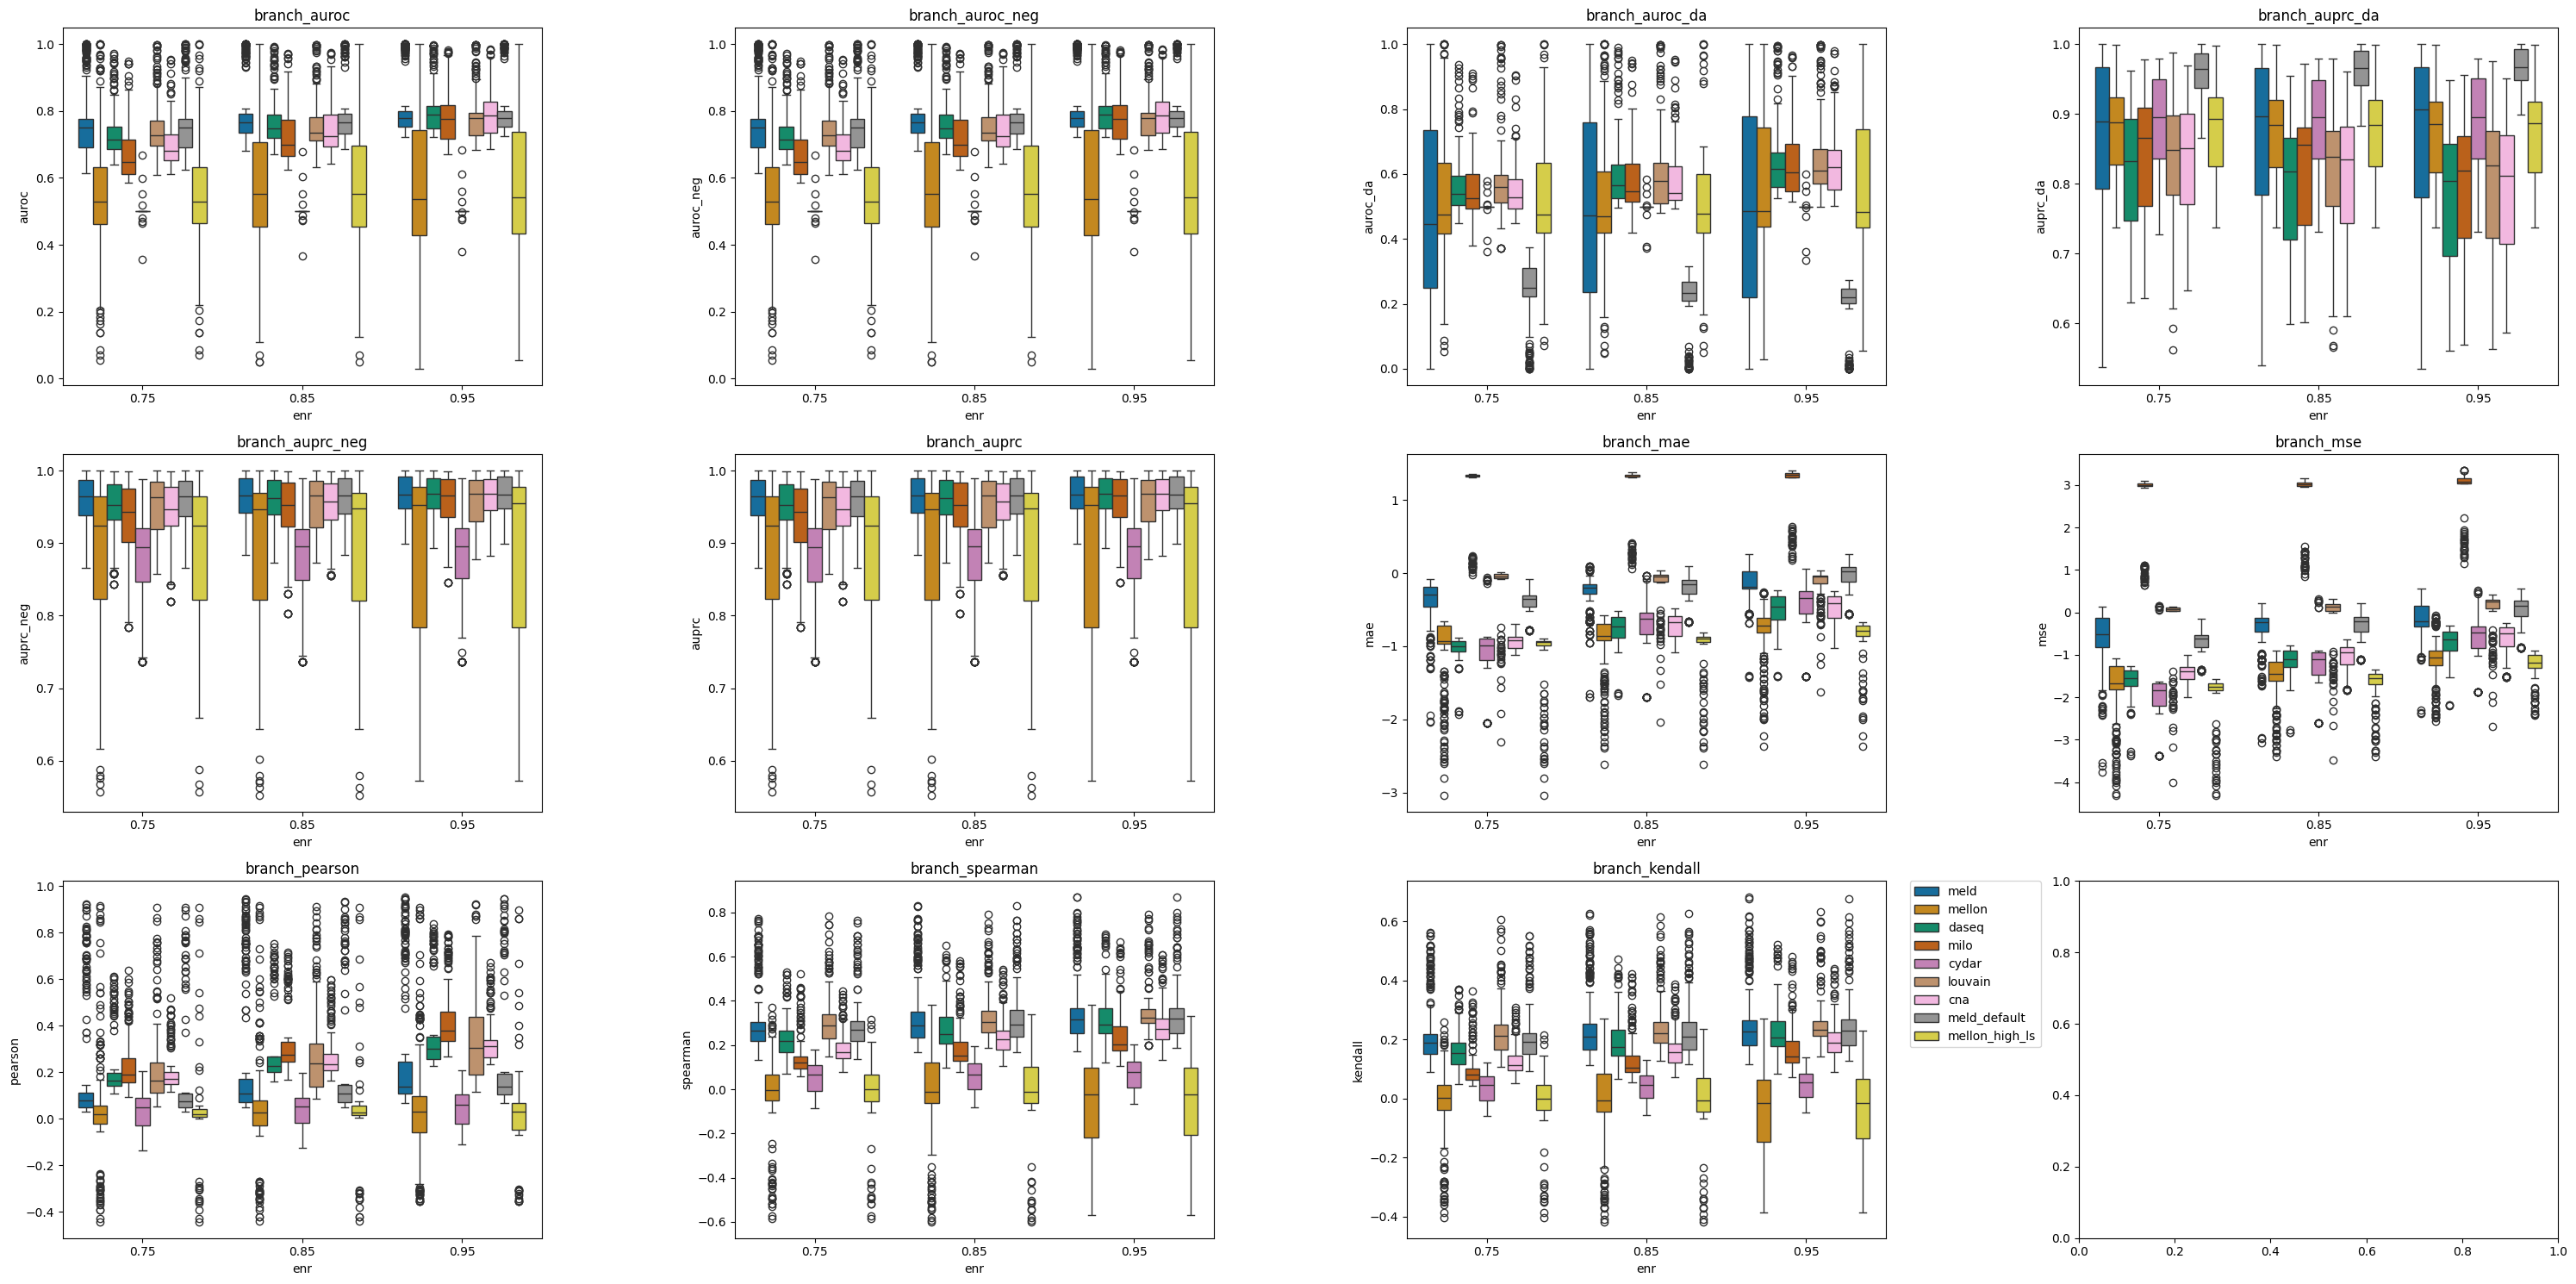

In [45]:
#"auprc_pos","auroc_pos"
# metrics = ["auroc","auroc_neg","auprc_neg","auprc","mae","mse","pearson",
#            "spearman","kendall"]
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_with_aging_dm_testing_0224/synthetic/linear/linear-M1-0.75-43-1.5-No-mellon_pca-fractal-No-Yes-No/iteration_0/benchmark_linear_pop_M1_enr0.75_seed43_batchEffect1.5_package_performance.DAresults.cydar.csv'

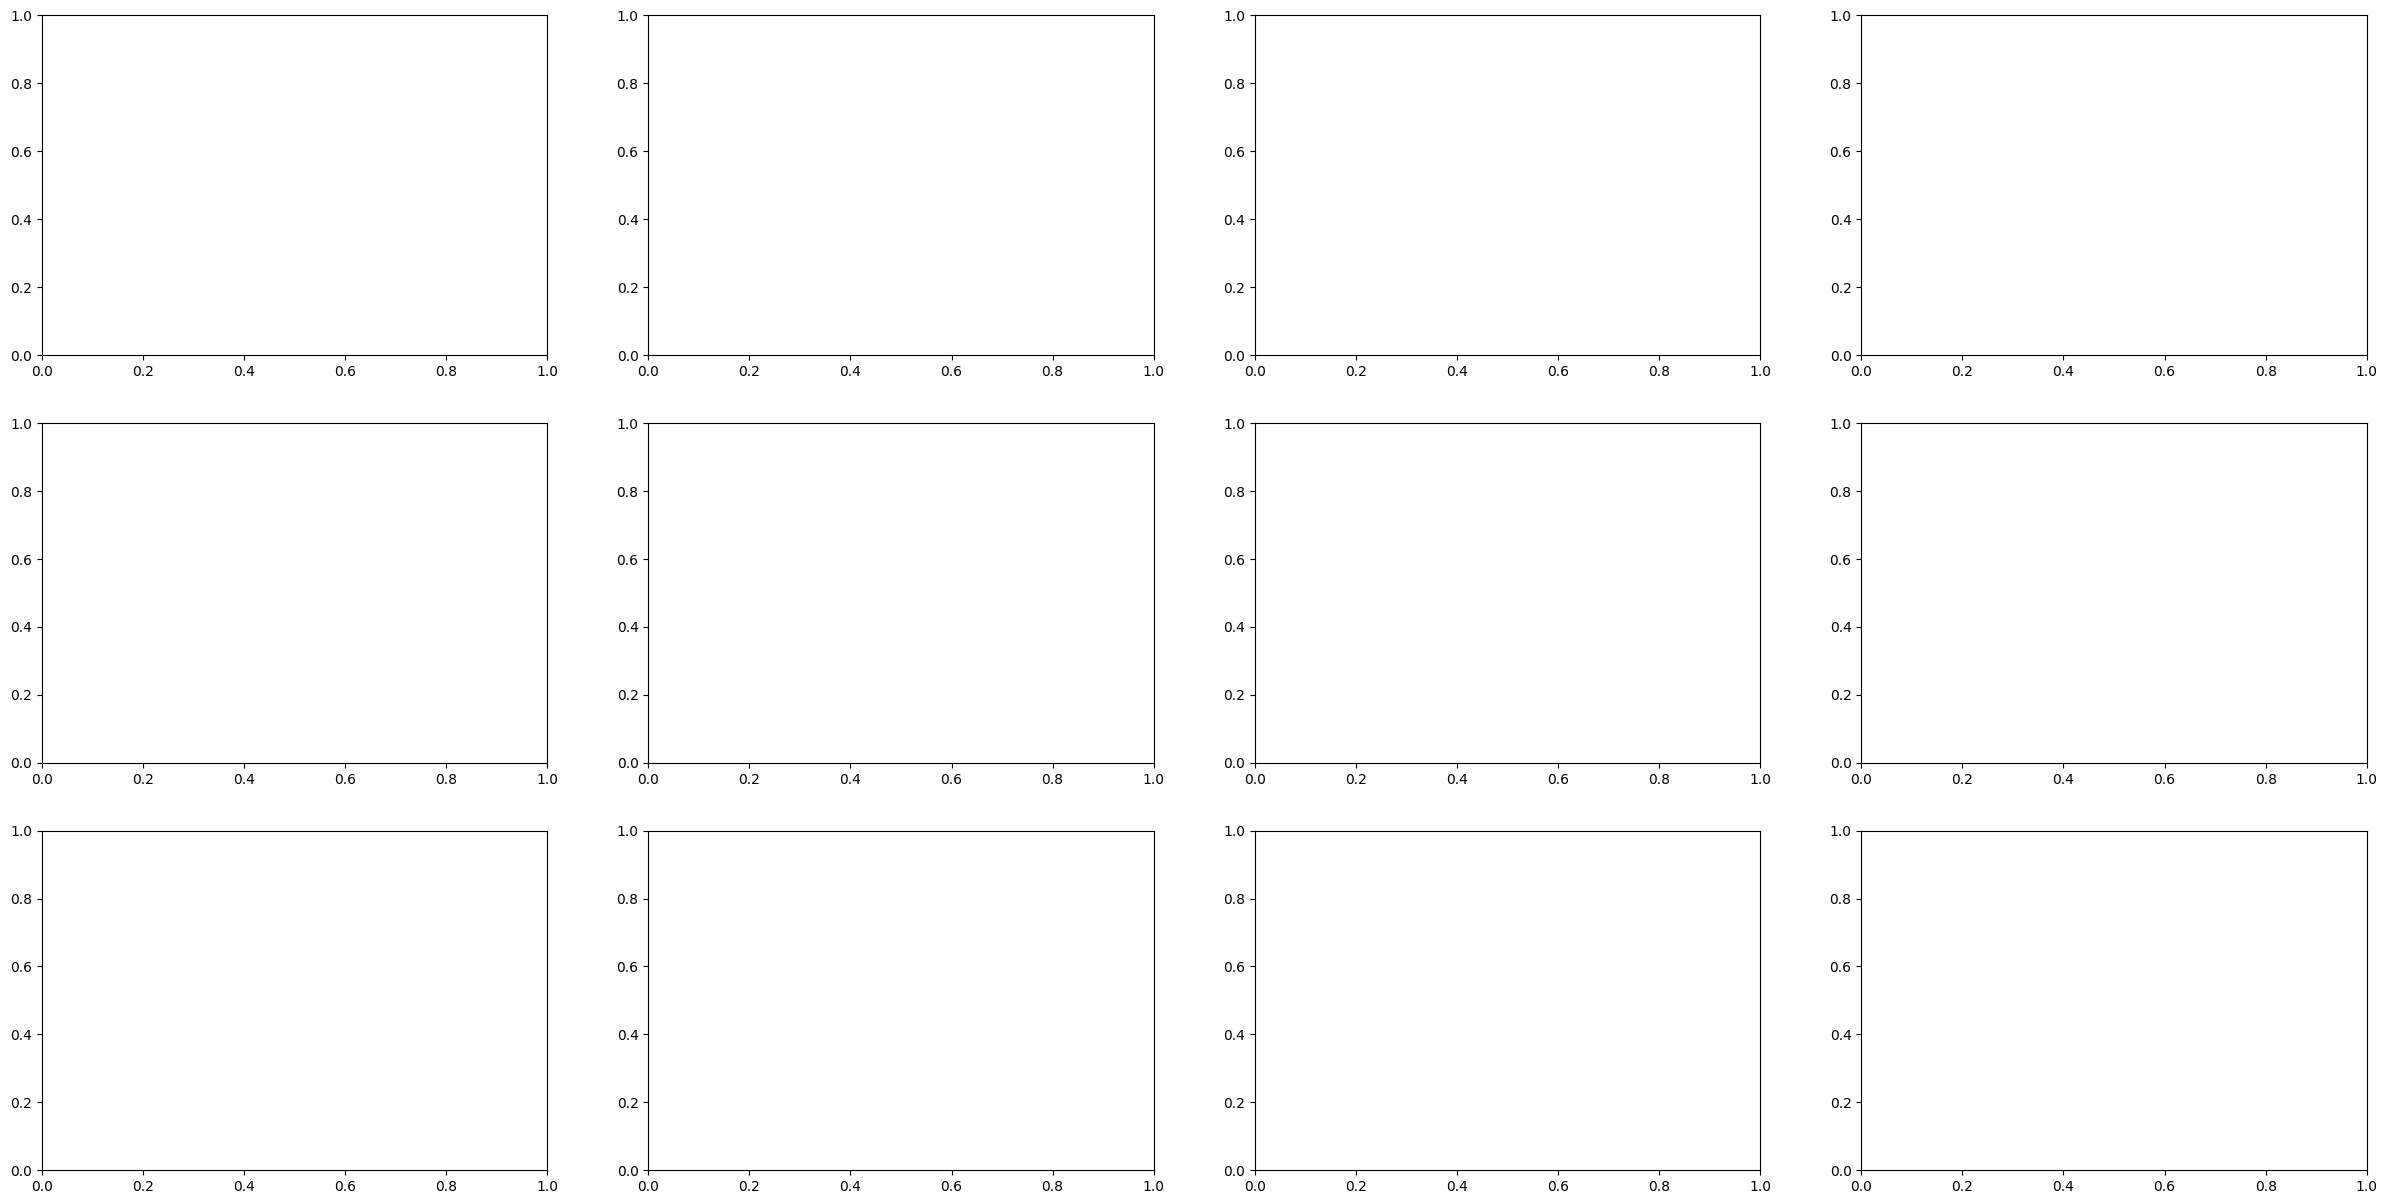

In [46]:
#"auprc_pos","auroc_pos"
# metrics = ["auroc","auroc_neg","auprc_neg","auprc","mae","mse","pearson",
#            "spearman","kendall"]
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

In [100]:
### Check the new version mellon produced results

In [202]:
def get_performance_batch(ds,metrics,ax,designed_palette_final):
    # ,ax,designed_palette_final
    result_dict,ground_truth_dict = get_results(ds)
    #performance_dict,ground_truth_dict
    performance_dict = {}
    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
        #,"0.75","1","1.25","1.5"
    performance_dict = {}
    for i in ["0"]:
        ## No batch effect added in this case
        for j in ["43","44","45"]:
                for l in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        ground_truth_df = ground_truth_dict[i+"_"+j+"_"+w+"_"+l]
                        result_df = result_dict[i+"_"+j+"_"+w+"_"+l]
                        
#                         _, idx_1 = np.unique(ground_truth_df['lfc_truth'], return_index=True)
#                         mask_1 = np.zeros(len(ground_truth_df), dtype=bool)
#                         mask_1[idx_1] = True
                        
                        

                        
#                         ground_truth_df = ground_truth_df[mask_1]
#                         result_df = result_df[mask_1]
                        #for k in ["meld","mellon","cna","meld_default","mellon_high_ls"]:

                        for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
#                             _, idx_2 = np.unique(result_df[k], return_index=True)
#                             mask_2 = np.zeros(len(result_df[k]), dtype=bool)
#                             mask_2[idx_2] = True
                            
#                             ground_truth_df = ground_truth_df[mask_2]
#                             result_df = result_df[mask_2]
                            
                            if metrics == "auroc":
                                score = modified_auroc(ground_truth_df, result_df,k)["mean_auroc"]
                            elif metrics == "auroc_neg":
                                score = modified_auroc(ground_truth_df, result_df,k)["neg_auroc"]
                            elif metrics == "auroc_da":
                                score = modified_auroc(ground_truth_df, result_df,k)["da_auroc"]
                            elif metrics == "auprc_neg":
                                score = modified_auprc(ground_truth_df, result_df,k)["neg_auprc"]
                            elif metrics == "auprc_da":
                                score = modified_auprc(ground_truth_df, result_df,k)["da_auprc"]
                            elif metrics == "auprc":
                                score = modified_auprc(ground_truth_df, result_df,k)["mean_auprc"]
                            elif metrics == "mae":
                                score = np.log(calculate_mae(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "mse":
                                score = np.log(calculate_mse(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "pearson":
                                score = calculate_pearson_correlation(ground_truth_df, result_df,k)
                            # elif metrics == "r2":
                            #     score = calculate_r2(ground_truth_df, result_df,k)
                            elif metrics == "spearman":
                                score = compare_ranks_spearman(ground_truth_df, result_df,k)
                            elif metrics == "kendall":
                                score = compare_ranks_kendall(ground_truth_df, result_df,k)
                            # elif metrics == "rbo":
                            #     score = calculate_rbo(ground_truth_df, result_df,k)
                            performance_dict[j+"_"+l+"_"+w+"_"+i+"_"+k] = score
                            
    general_performance_df = pd.DataFrame()
    for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
        auroc_ds_0 = []
        auroc_ds_75 = []
        auroc_ds_1 = []
        auroc_ds_125 = []
        auroc_ds_15 = []
        strings = k.split("_")
        for i in list(performance_dict.keys()):
            if len(strings) > 1:
                temp_k = strings[0]+"_"+strings[1]
                if "0_"+temp_k in i:
                    auroc_ds_0.append(performance_dict[i])
                elif "0.75_"+temp_k in i:
                    auroc_ds_75.append(performance_dict[i])
                elif "1_"+temp_k in i:
                    auroc_ds_1.append(performance_dict[i])
                elif "1.25_"+temp_k in i:
                    auroc_ds_125.append(performance_dict[i])
                elif "1.5_"+temp_k in i:
                    auroc_ds_15.append(performance_dict[i])
            elif len(strings) == 1:
                final_i = i.split("_")
                temp_k = final_i[-2] + "_" + final_i[-1]
                if "0_"+k == temp_k:
                    auroc_ds_0.append(performance_dict[i])
                elif "0.75_"+k == temp_k:
                    auroc_ds_75.append(performance_dict[i])
                elif "1_"+k == temp_k:
                    auroc_ds_1.append(performance_dict[i])
                elif "1.25_"+k == temp_k:
                    auroc_ds_125.append(performance_dict[i])
                elif "1.5_"+k == temp_k:
                    auroc_ds_15.append(performance_dict[i])
                
                
            

        performance = metrics
        auroc_df_0_ds = pd.DataFrame({performance:auroc_ds_0,"package": [k] * len(auroc_ds_0),"batch":["0"]* len(auroc_ds_0)})
        auroc_df_75_ds = pd.DataFrame({performance:auroc_ds_75,"package": [k] * len(auroc_ds_75),"batch":["0.75"]* len(auroc_ds_75)})
        auroc_df_1_ds = pd.DataFrame({performance:auroc_ds_1,"package": [k] * len(auroc_ds_1),"batch":["1"]* len(auroc_ds_1)})
        auroc_df_125_ds = pd.DataFrame({performance:auroc_ds_125,"package": [k] * len(auroc_ds_125),"batch":["1.25"]* len(auroc_ds_125)})
        auroc_df_15_ds = pd.DataFrame({performance:auroc_ds_15,"package": [k] * len(auroc_ds_15),"batch":["1.5"]* len(auroc_ds_15)})
        
    

#         median_75_ds = pd.Series(auroc_df_75_ds[performance]).median()

#         median_85_ds = pd.Series(auroc_df_85_ds[performance]).median()
#         median_95_ds = pd.Series(auroc_df_95_ds[performance]).median()

#         median_list = [median_75_ds,median_85_ds,median_95_ds]
#         print(median_list)
    
    
        auroc_df = pd.concat([auroc_df_0_ds,auroc_df_75_ds, auroc_df_1_ds,auroc_df_125_ds,auroc_df_15_ds], ignore_index=True)
        
        general_performance_df = pd.concat([general_performance_df,auroc_df],ignore_index = True)
    
    plot = sns.boxplot(x = general_performance_df['batch'], 
            y = general_performance_df[performance], 
            hue = general_performance_df['package'],palette = designed_palette_final,ax = ax)
    #,palette = designed_palette_final,ax = ax
    return general_performance_df


### The below part are explorations, can be ignored

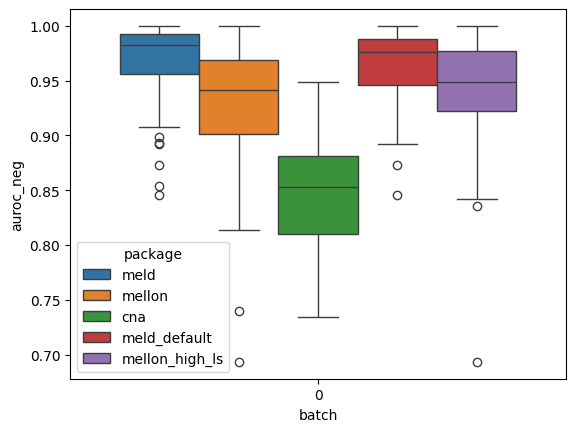

In [203]:
get_performance_batch("linear","auroc_neg")

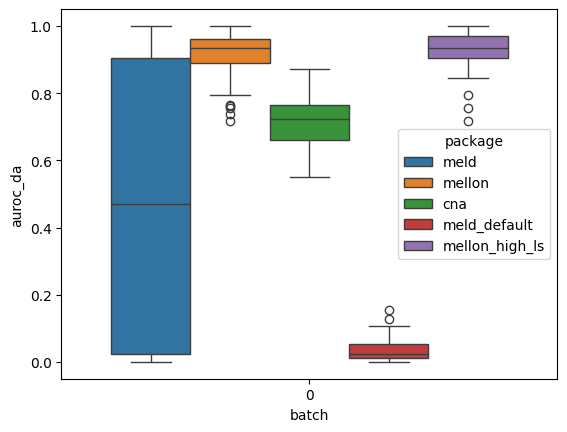

In [204]:
get_performance_batch("linear","auroc_da")

/loc/scratch/11397987/ipykernel_5552/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)
/loc/scratch/11397987/ipykernel_5552/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


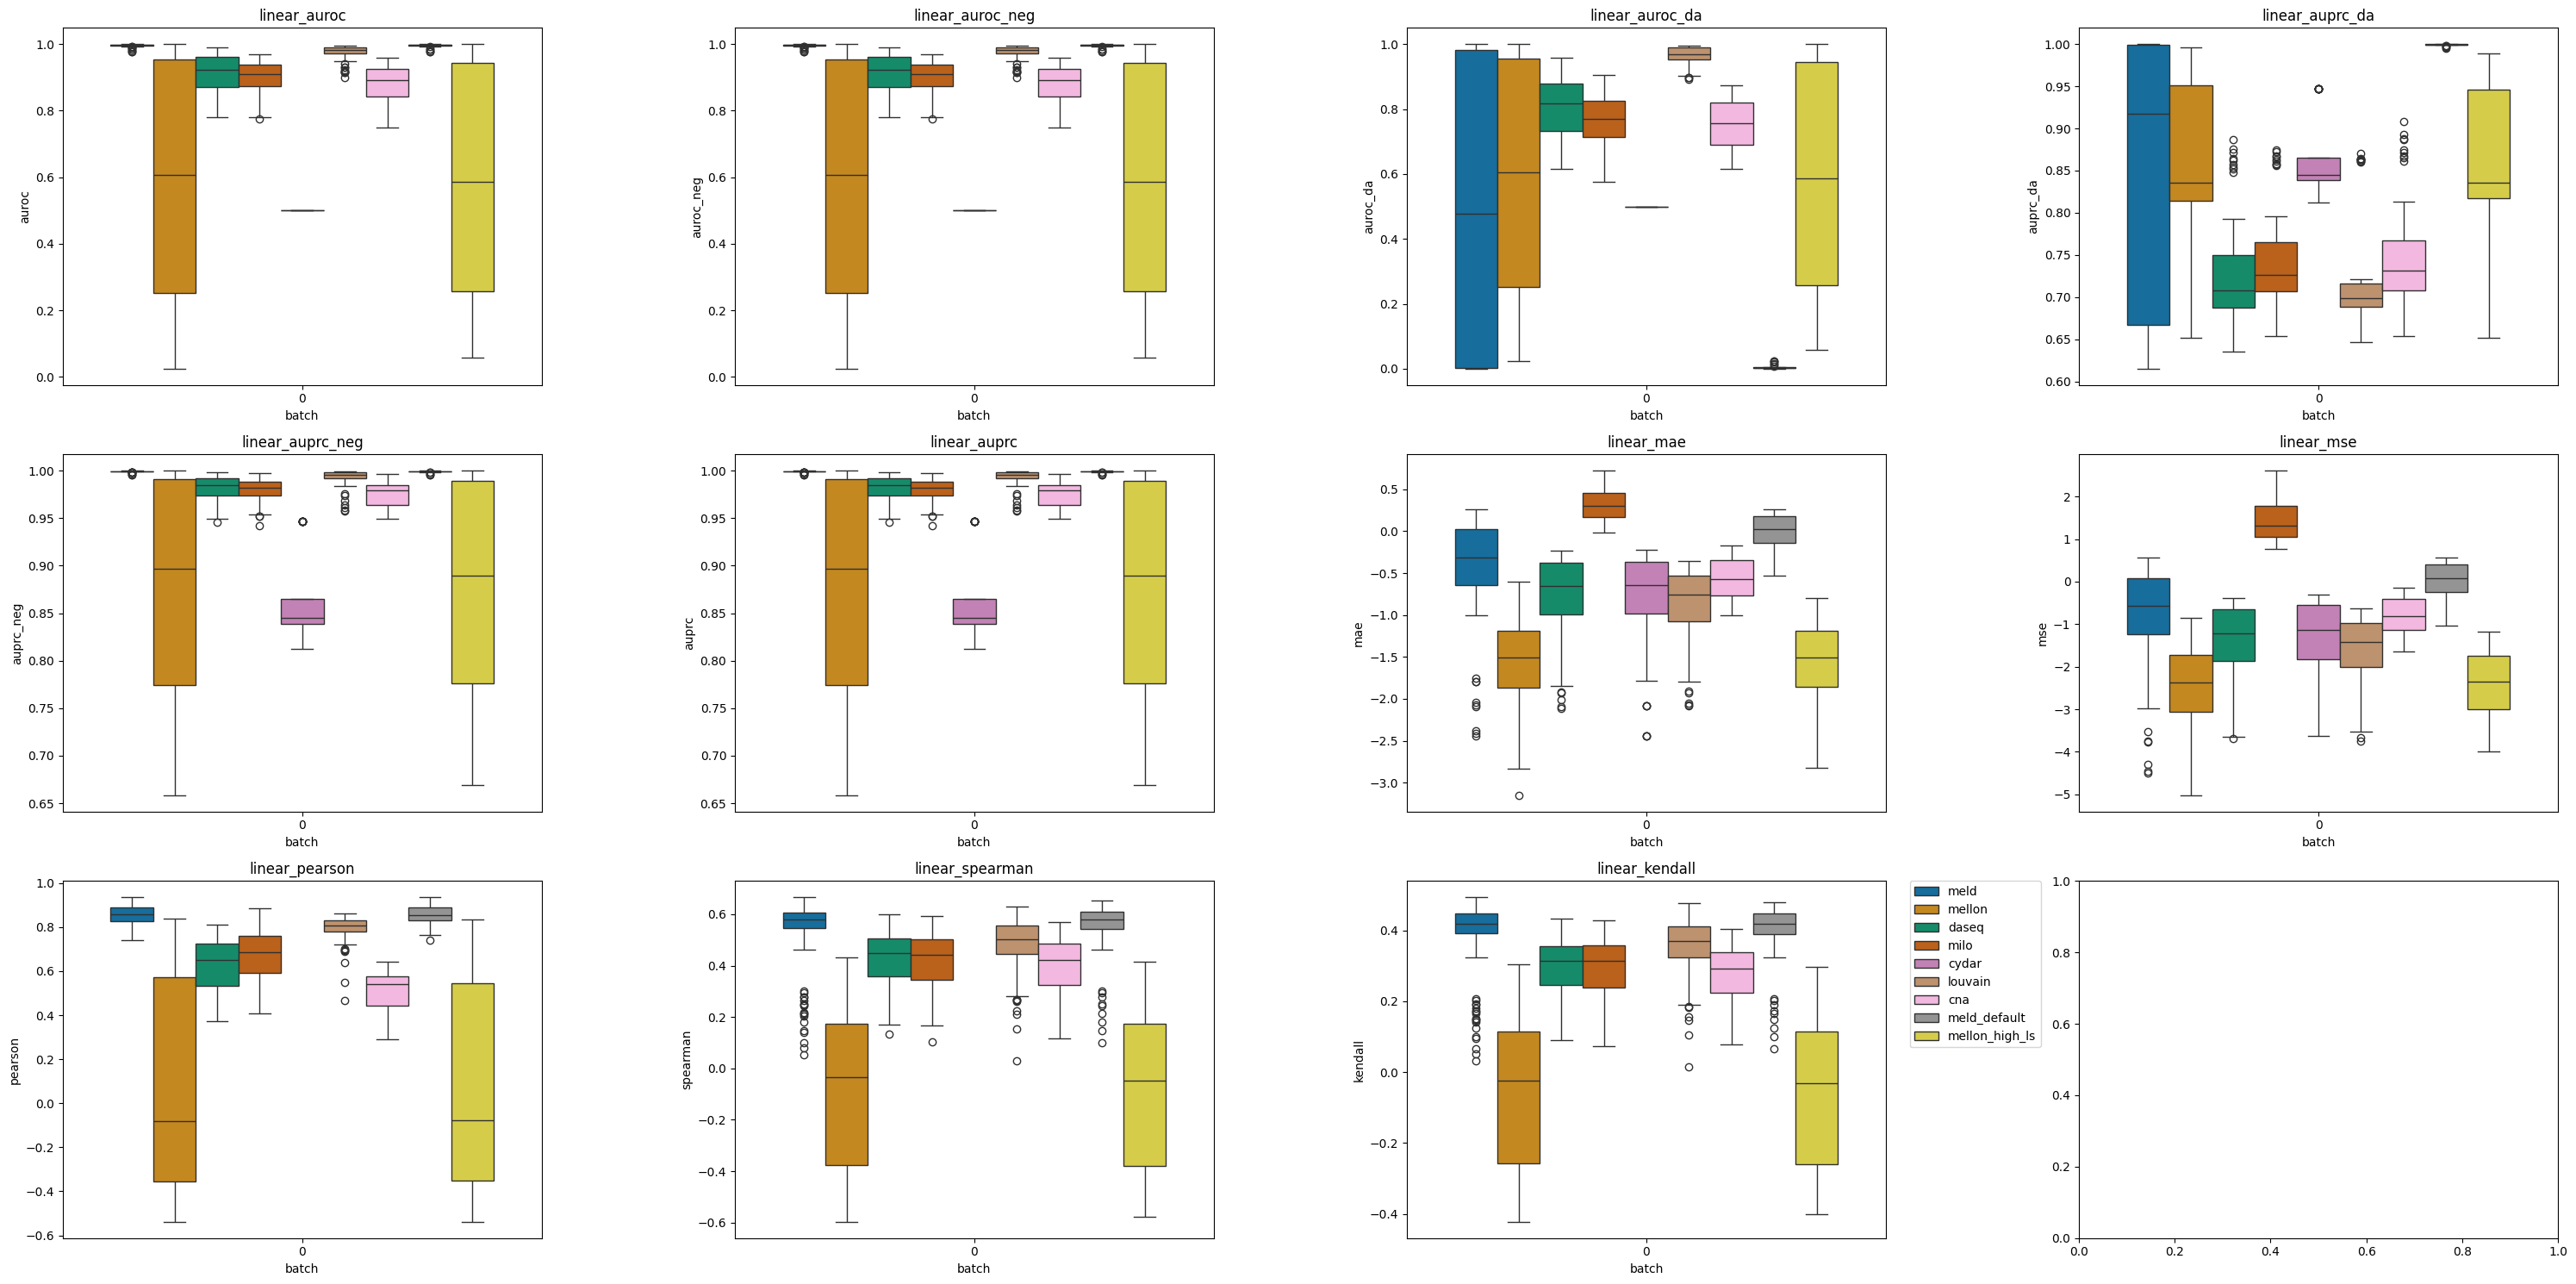

In [134]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)
/loc/scratch/11397987/ipykernel_5552/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


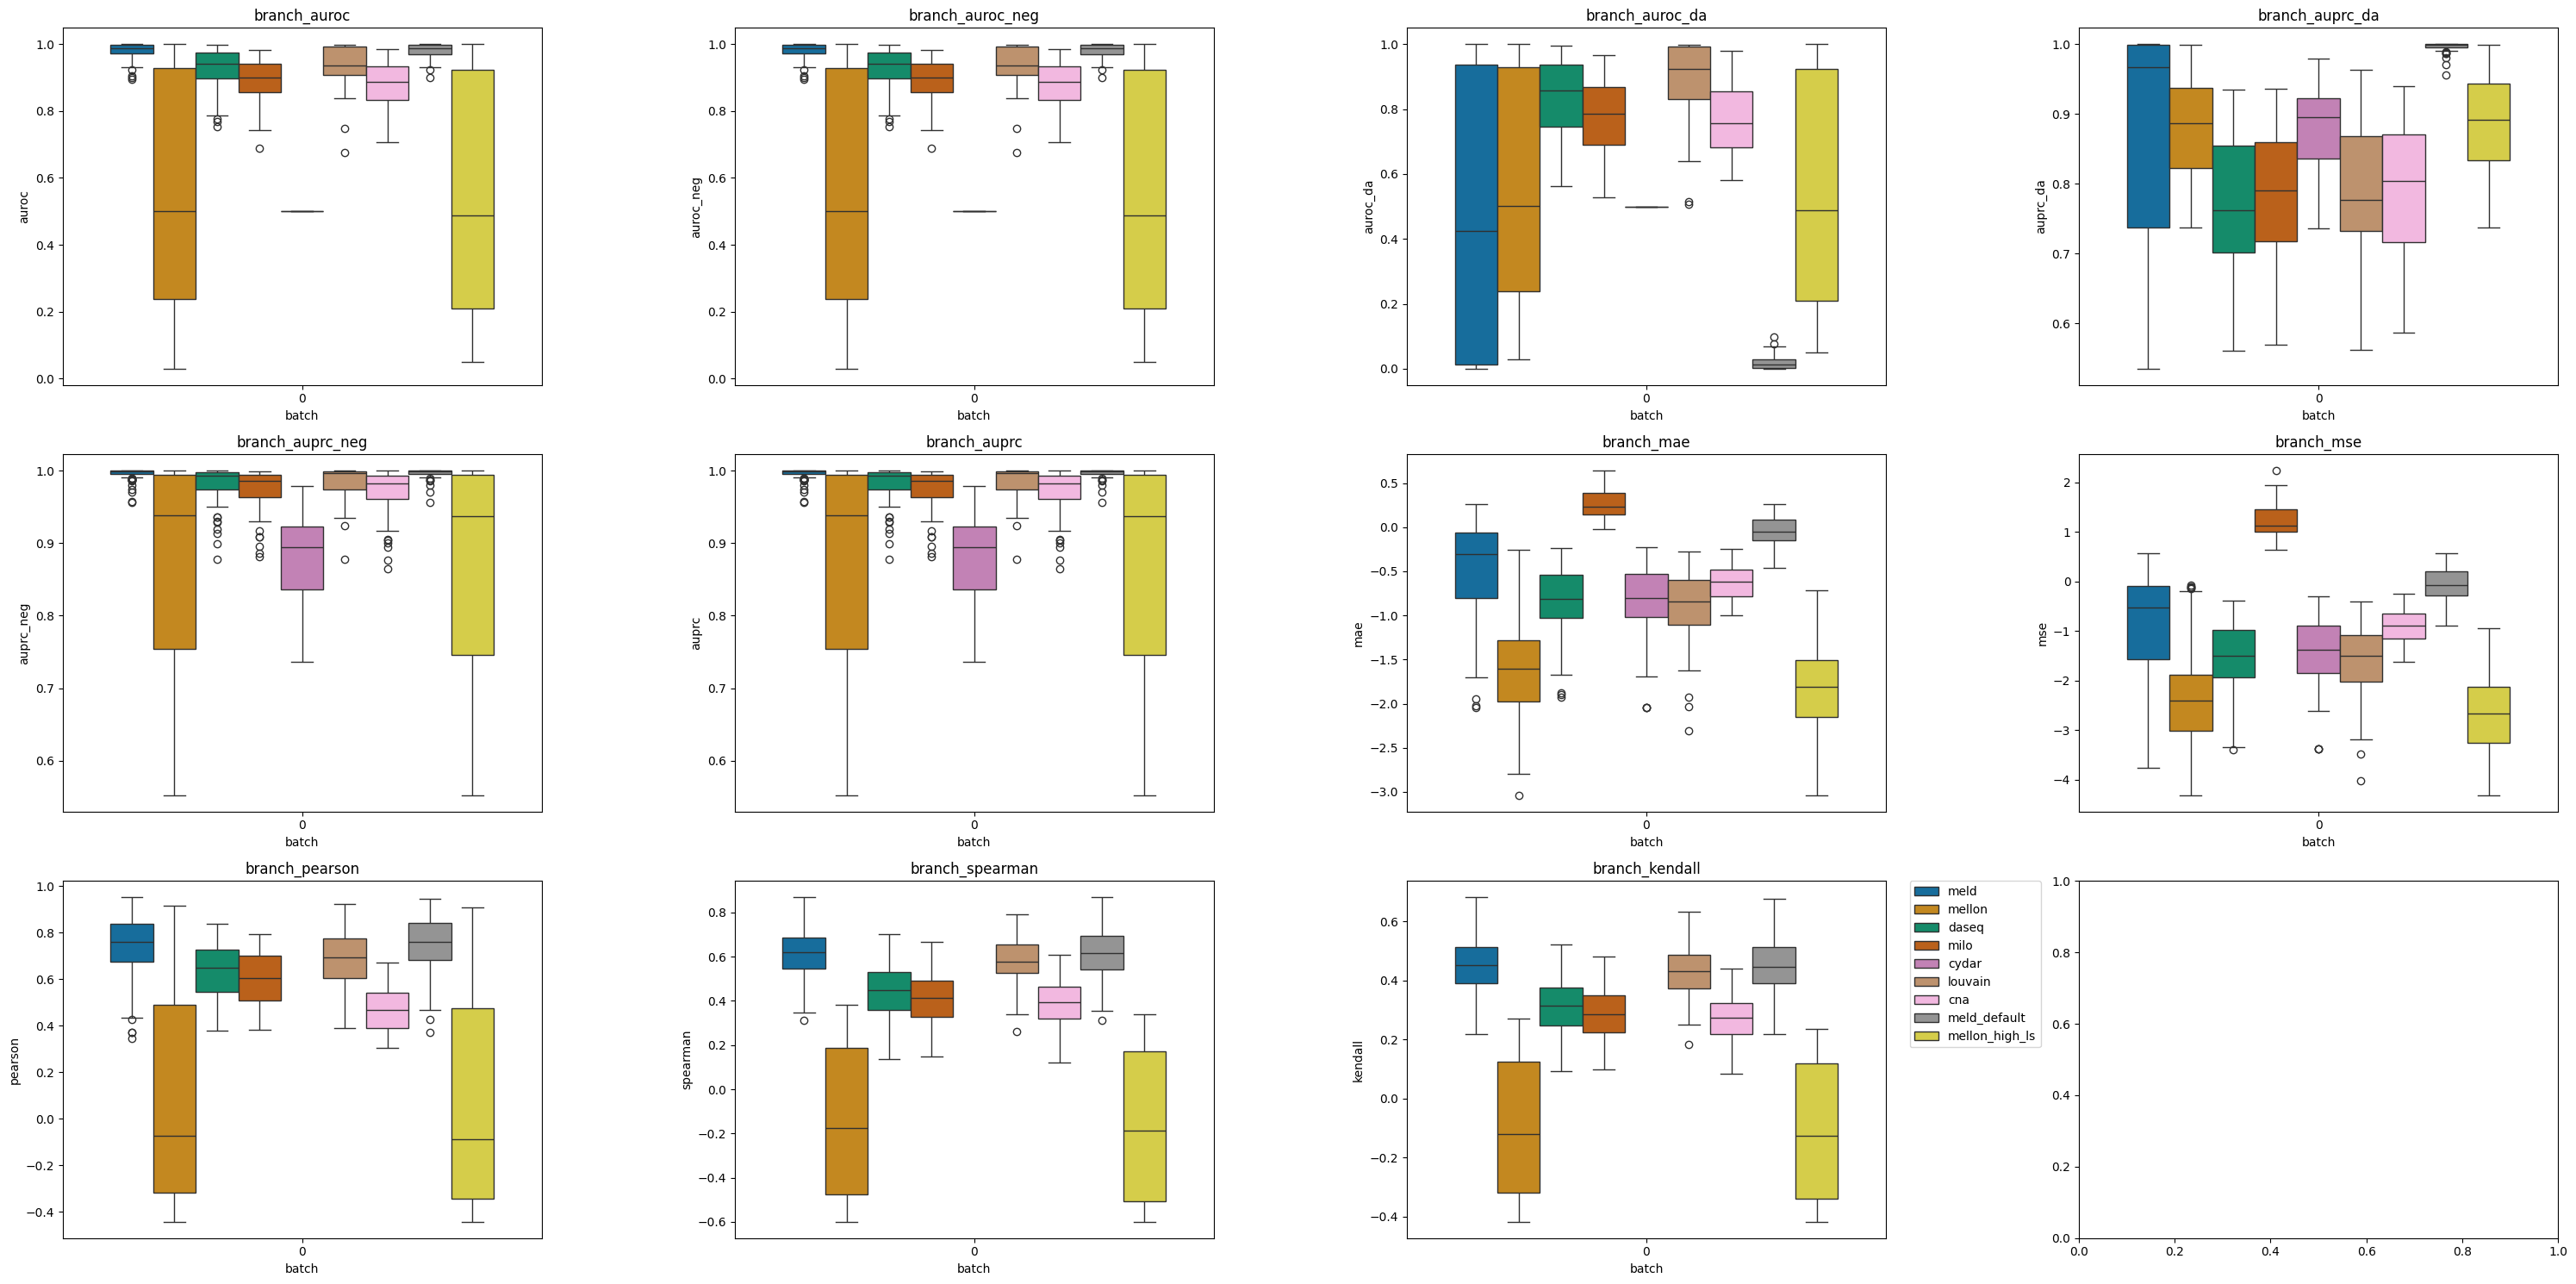

In [135]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)
/loc/scratch/11397987/ipykernel_5552/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


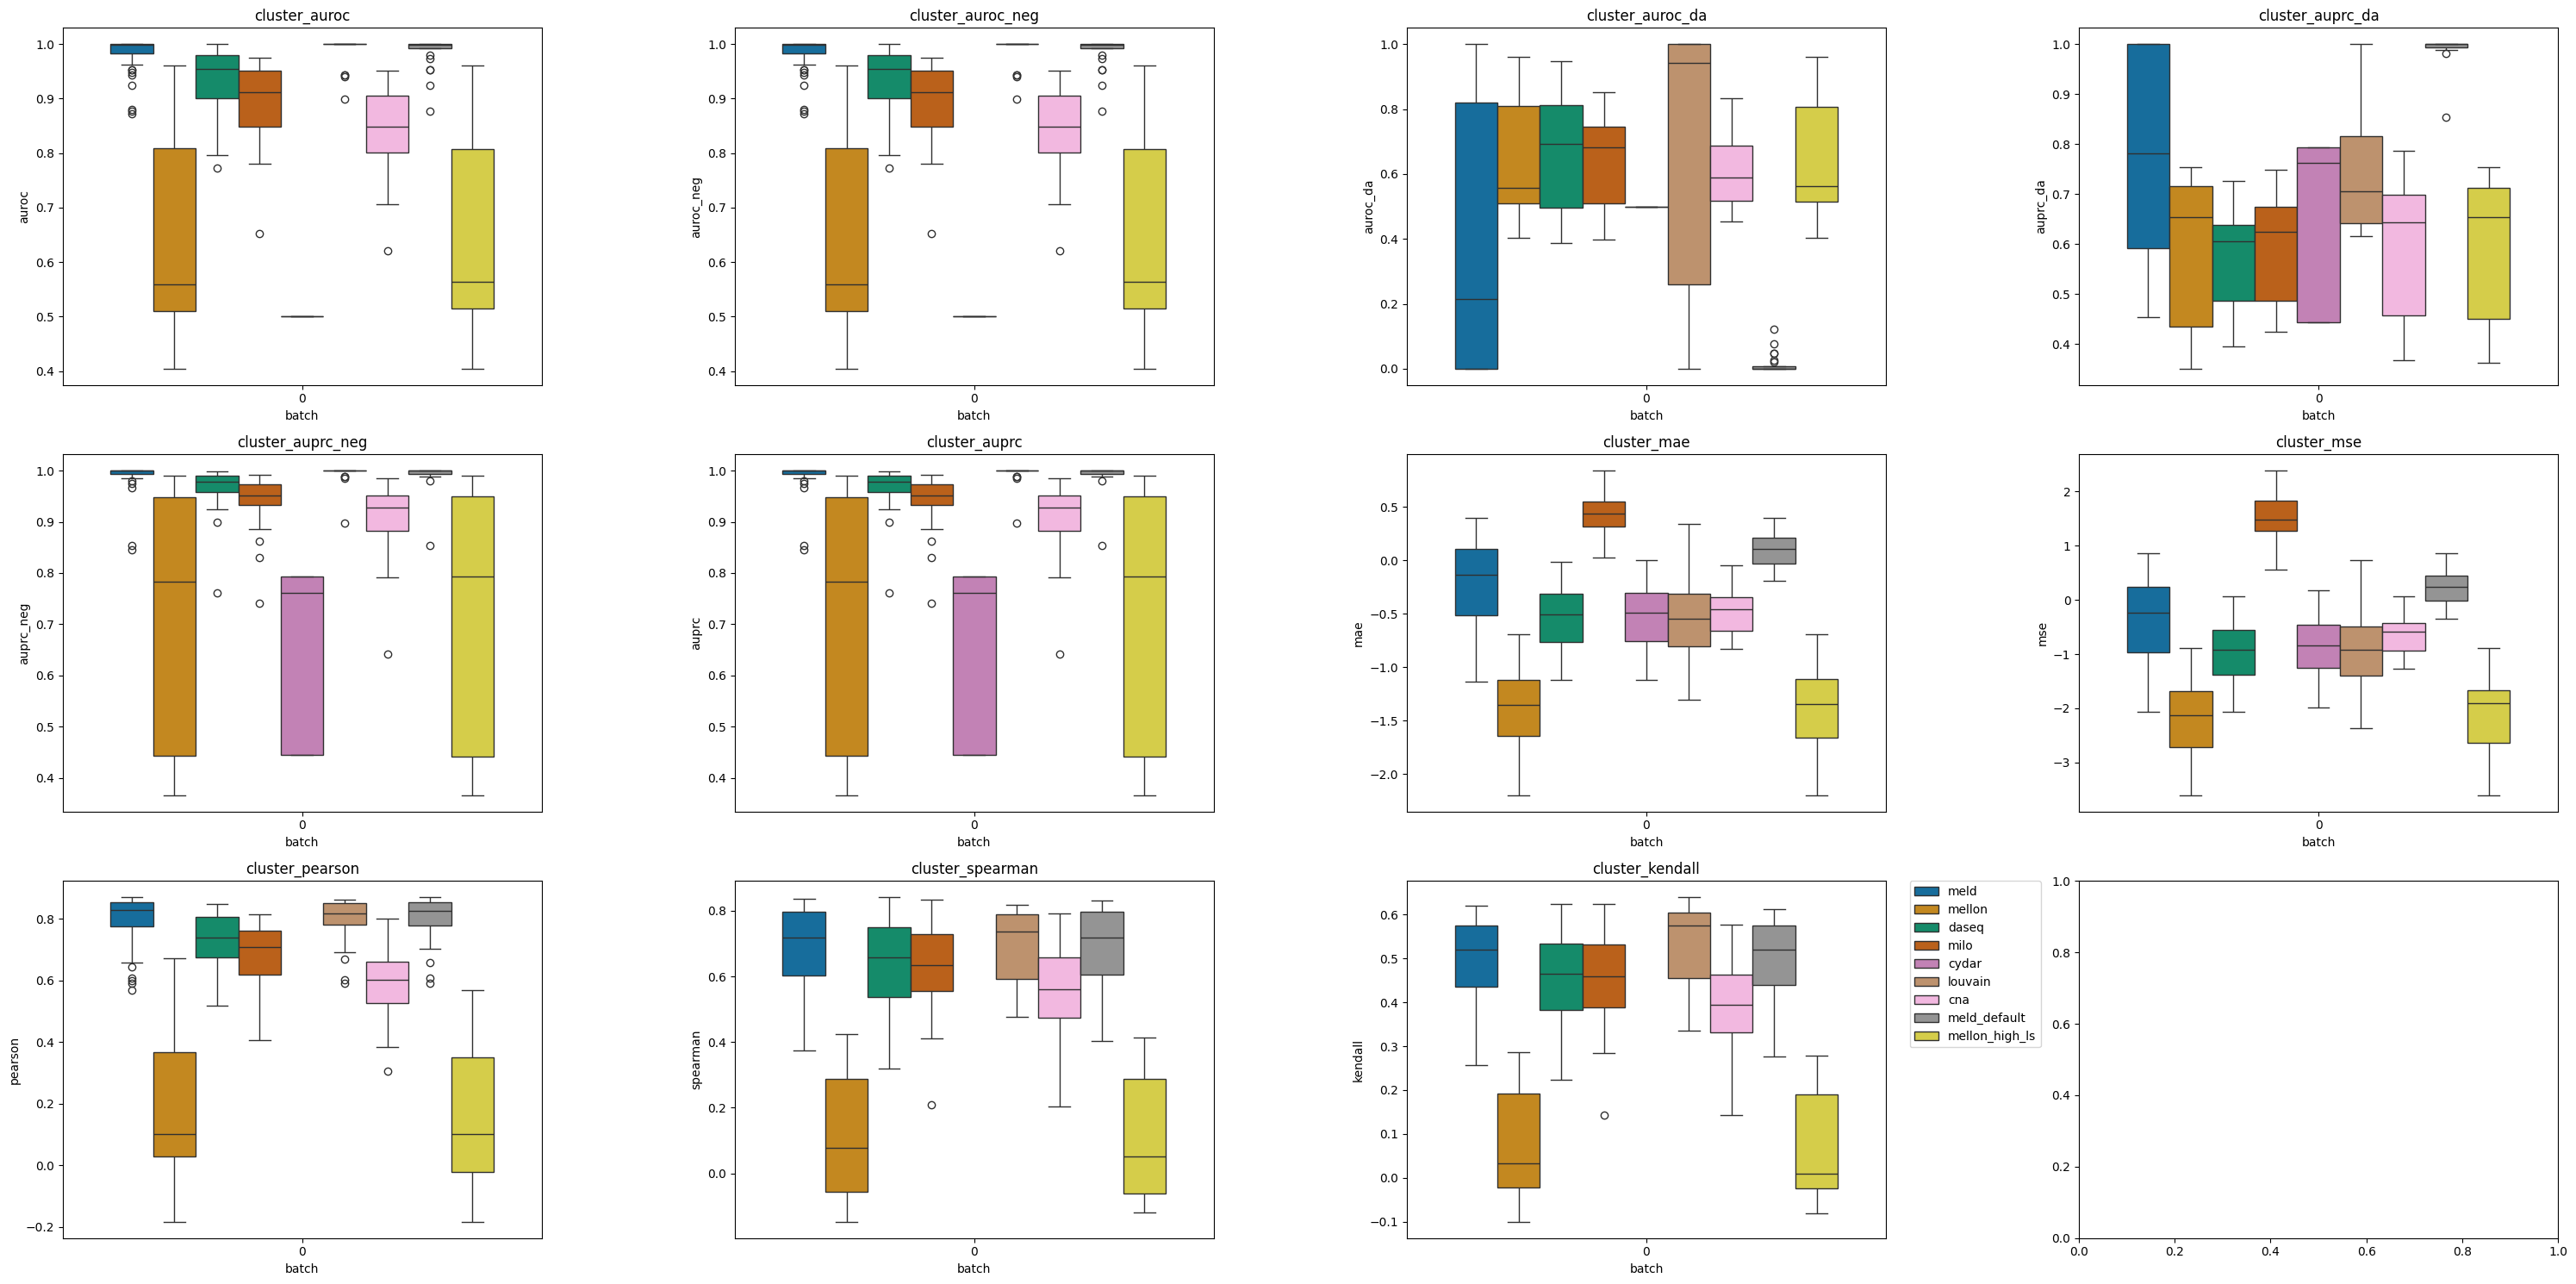

In [136]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

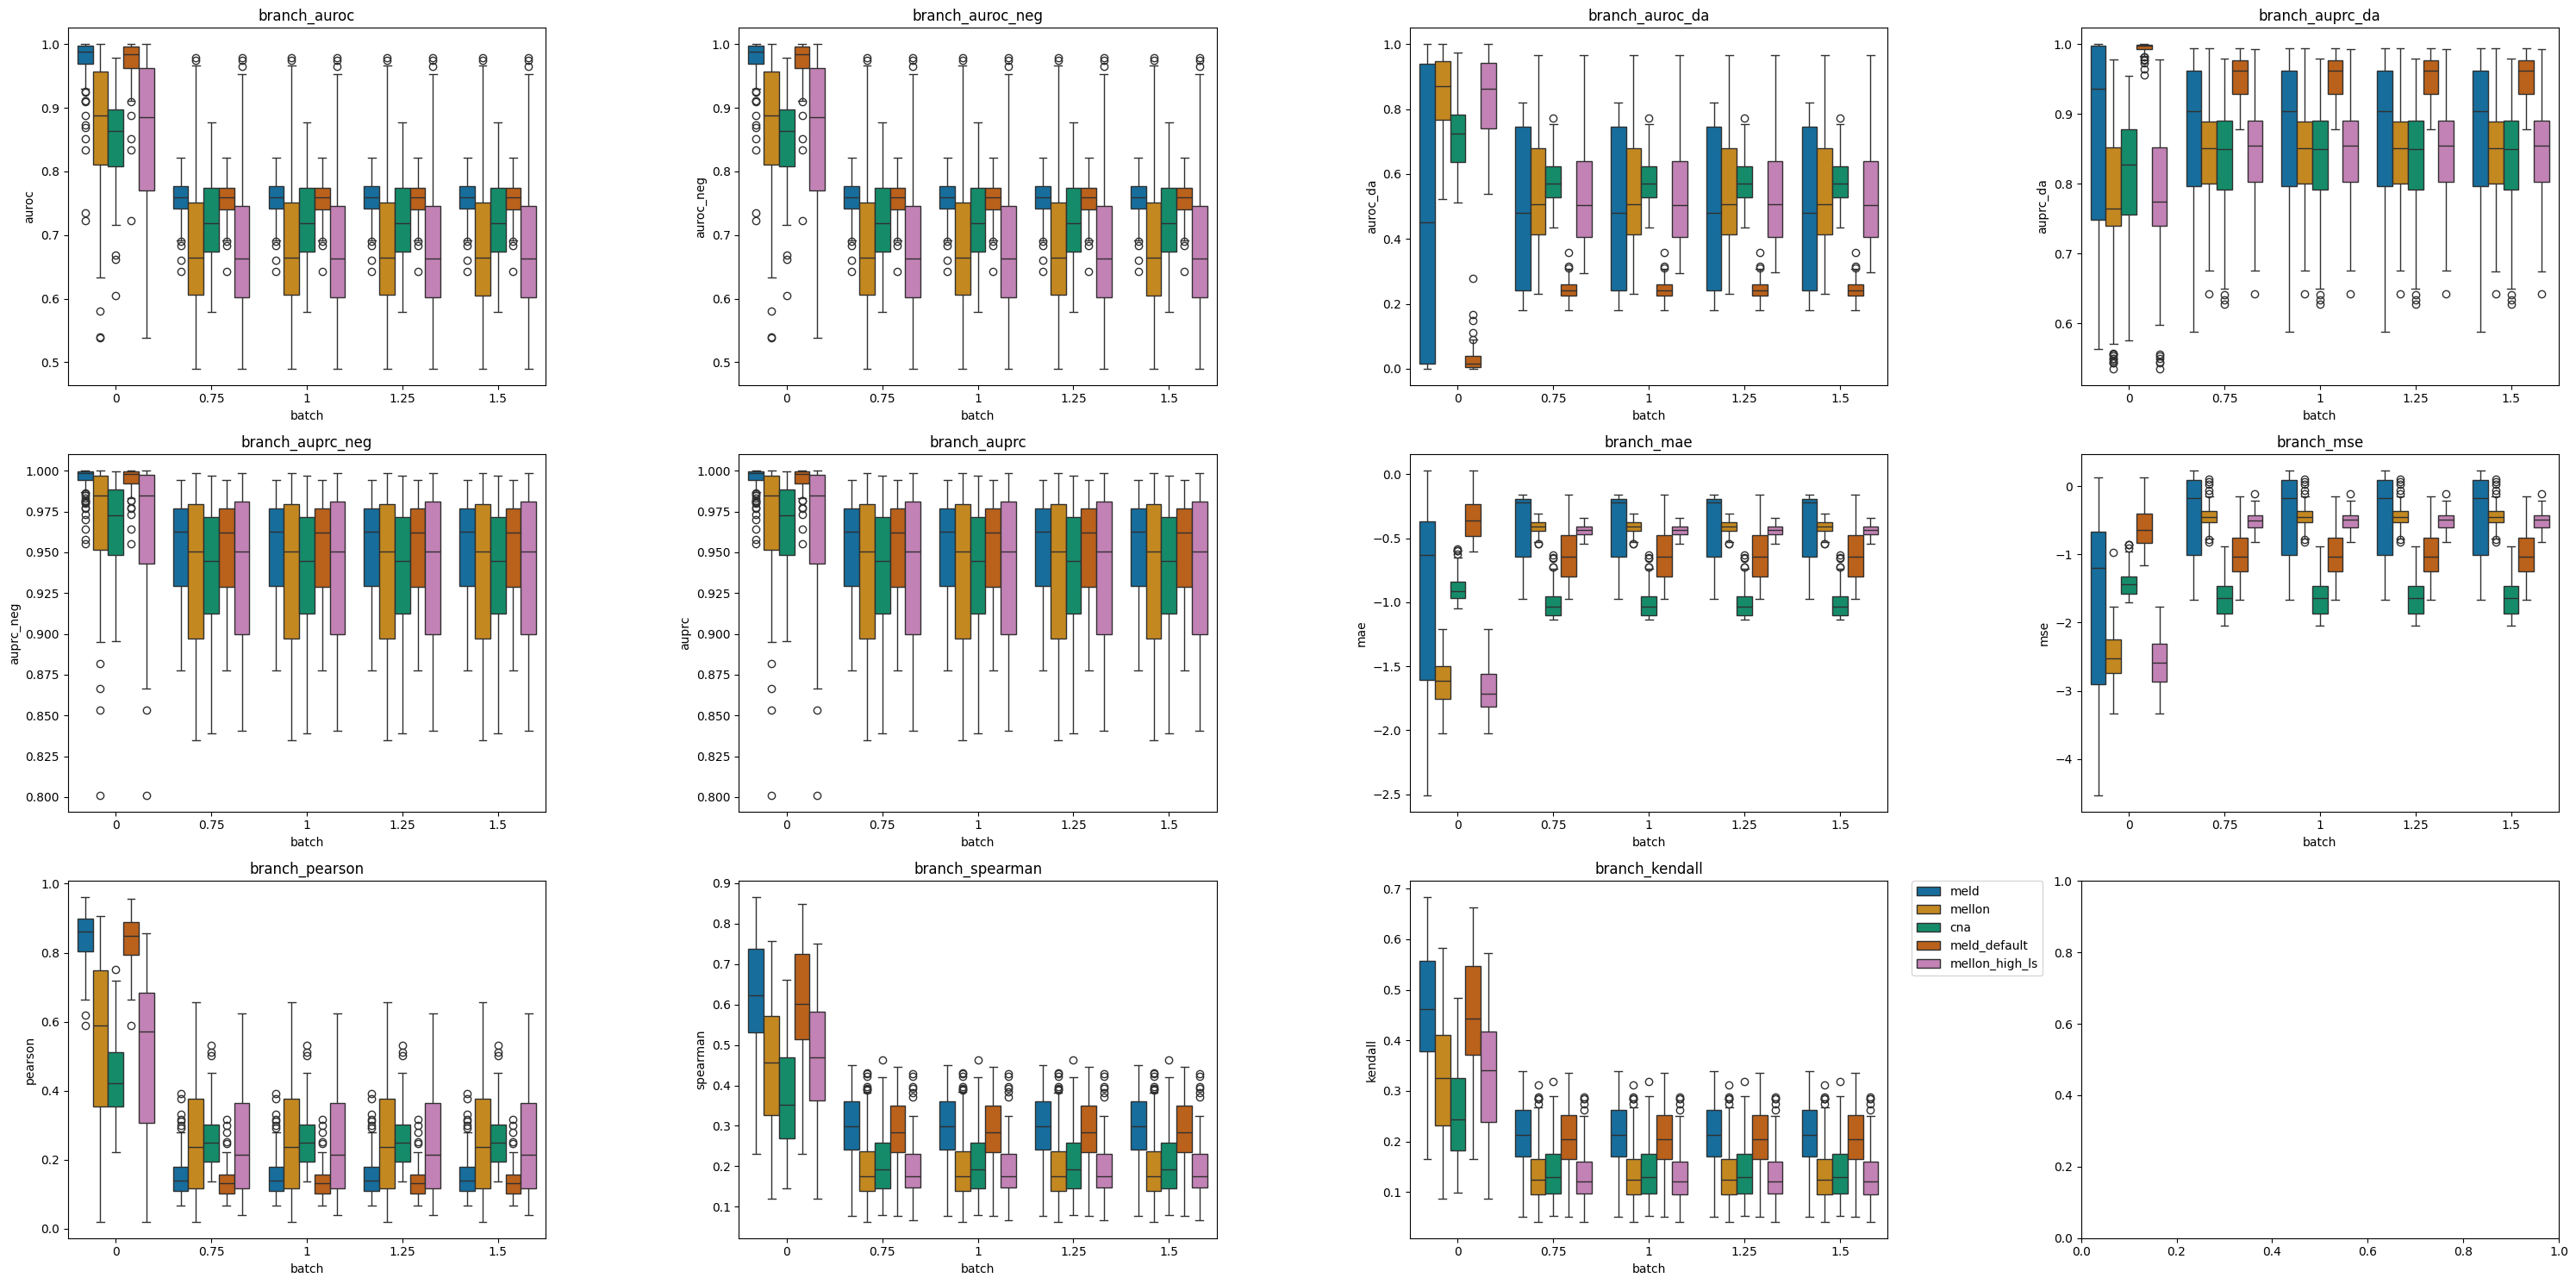

In [112]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

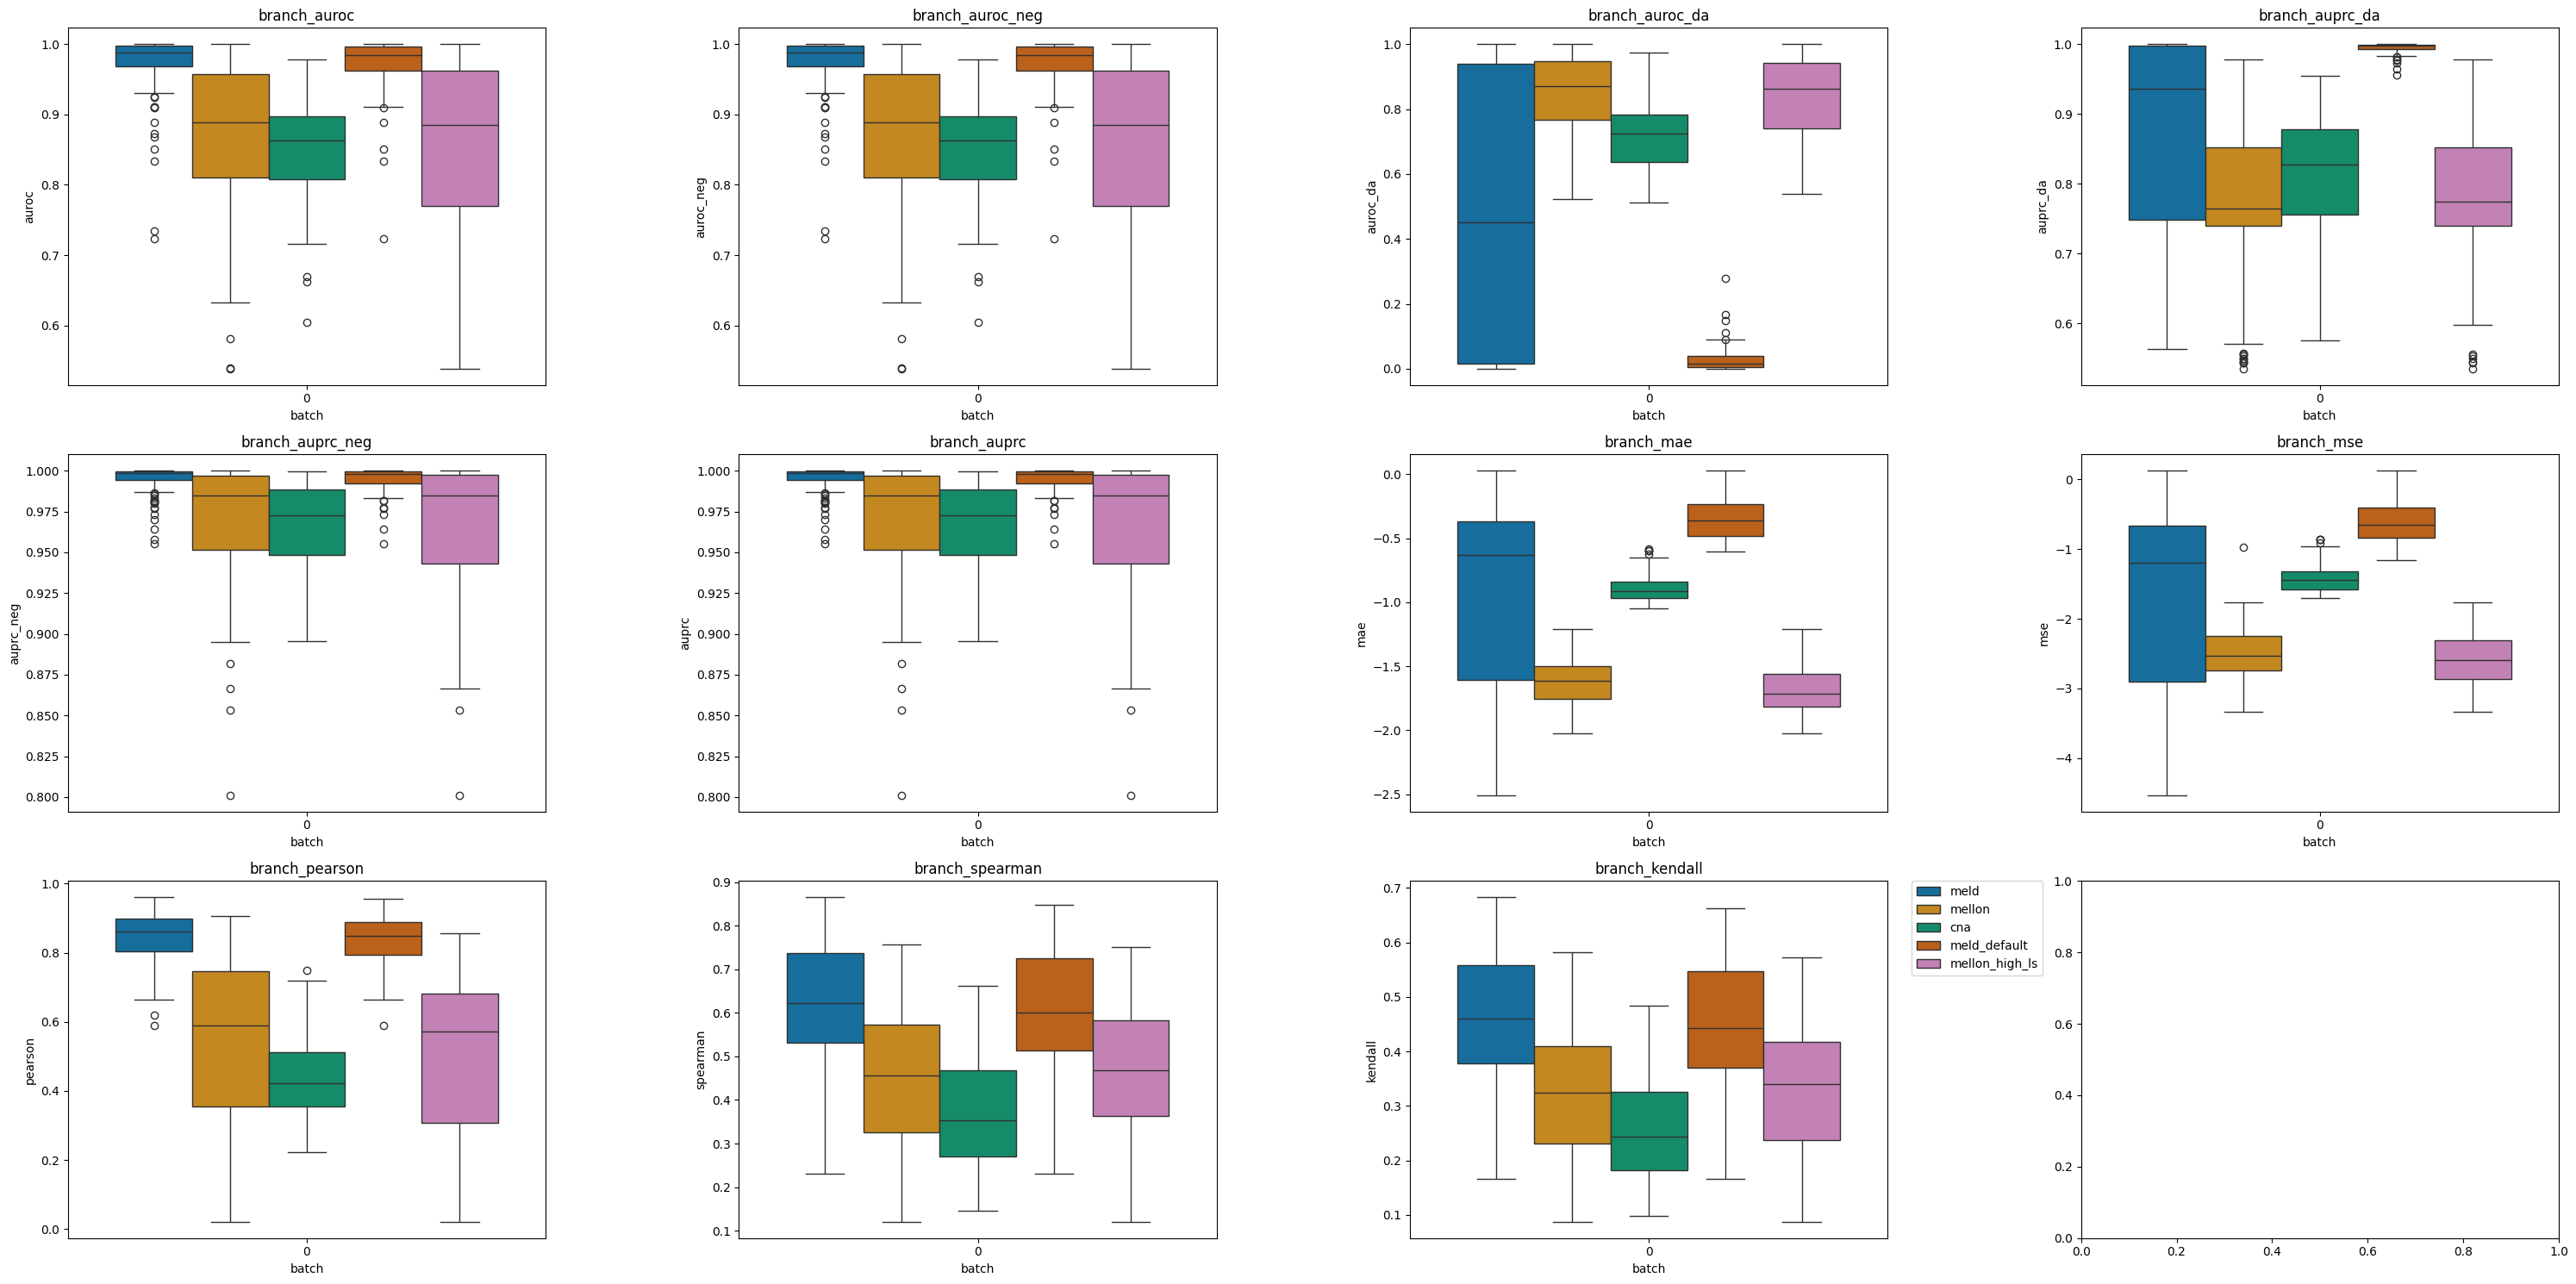

In [128]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

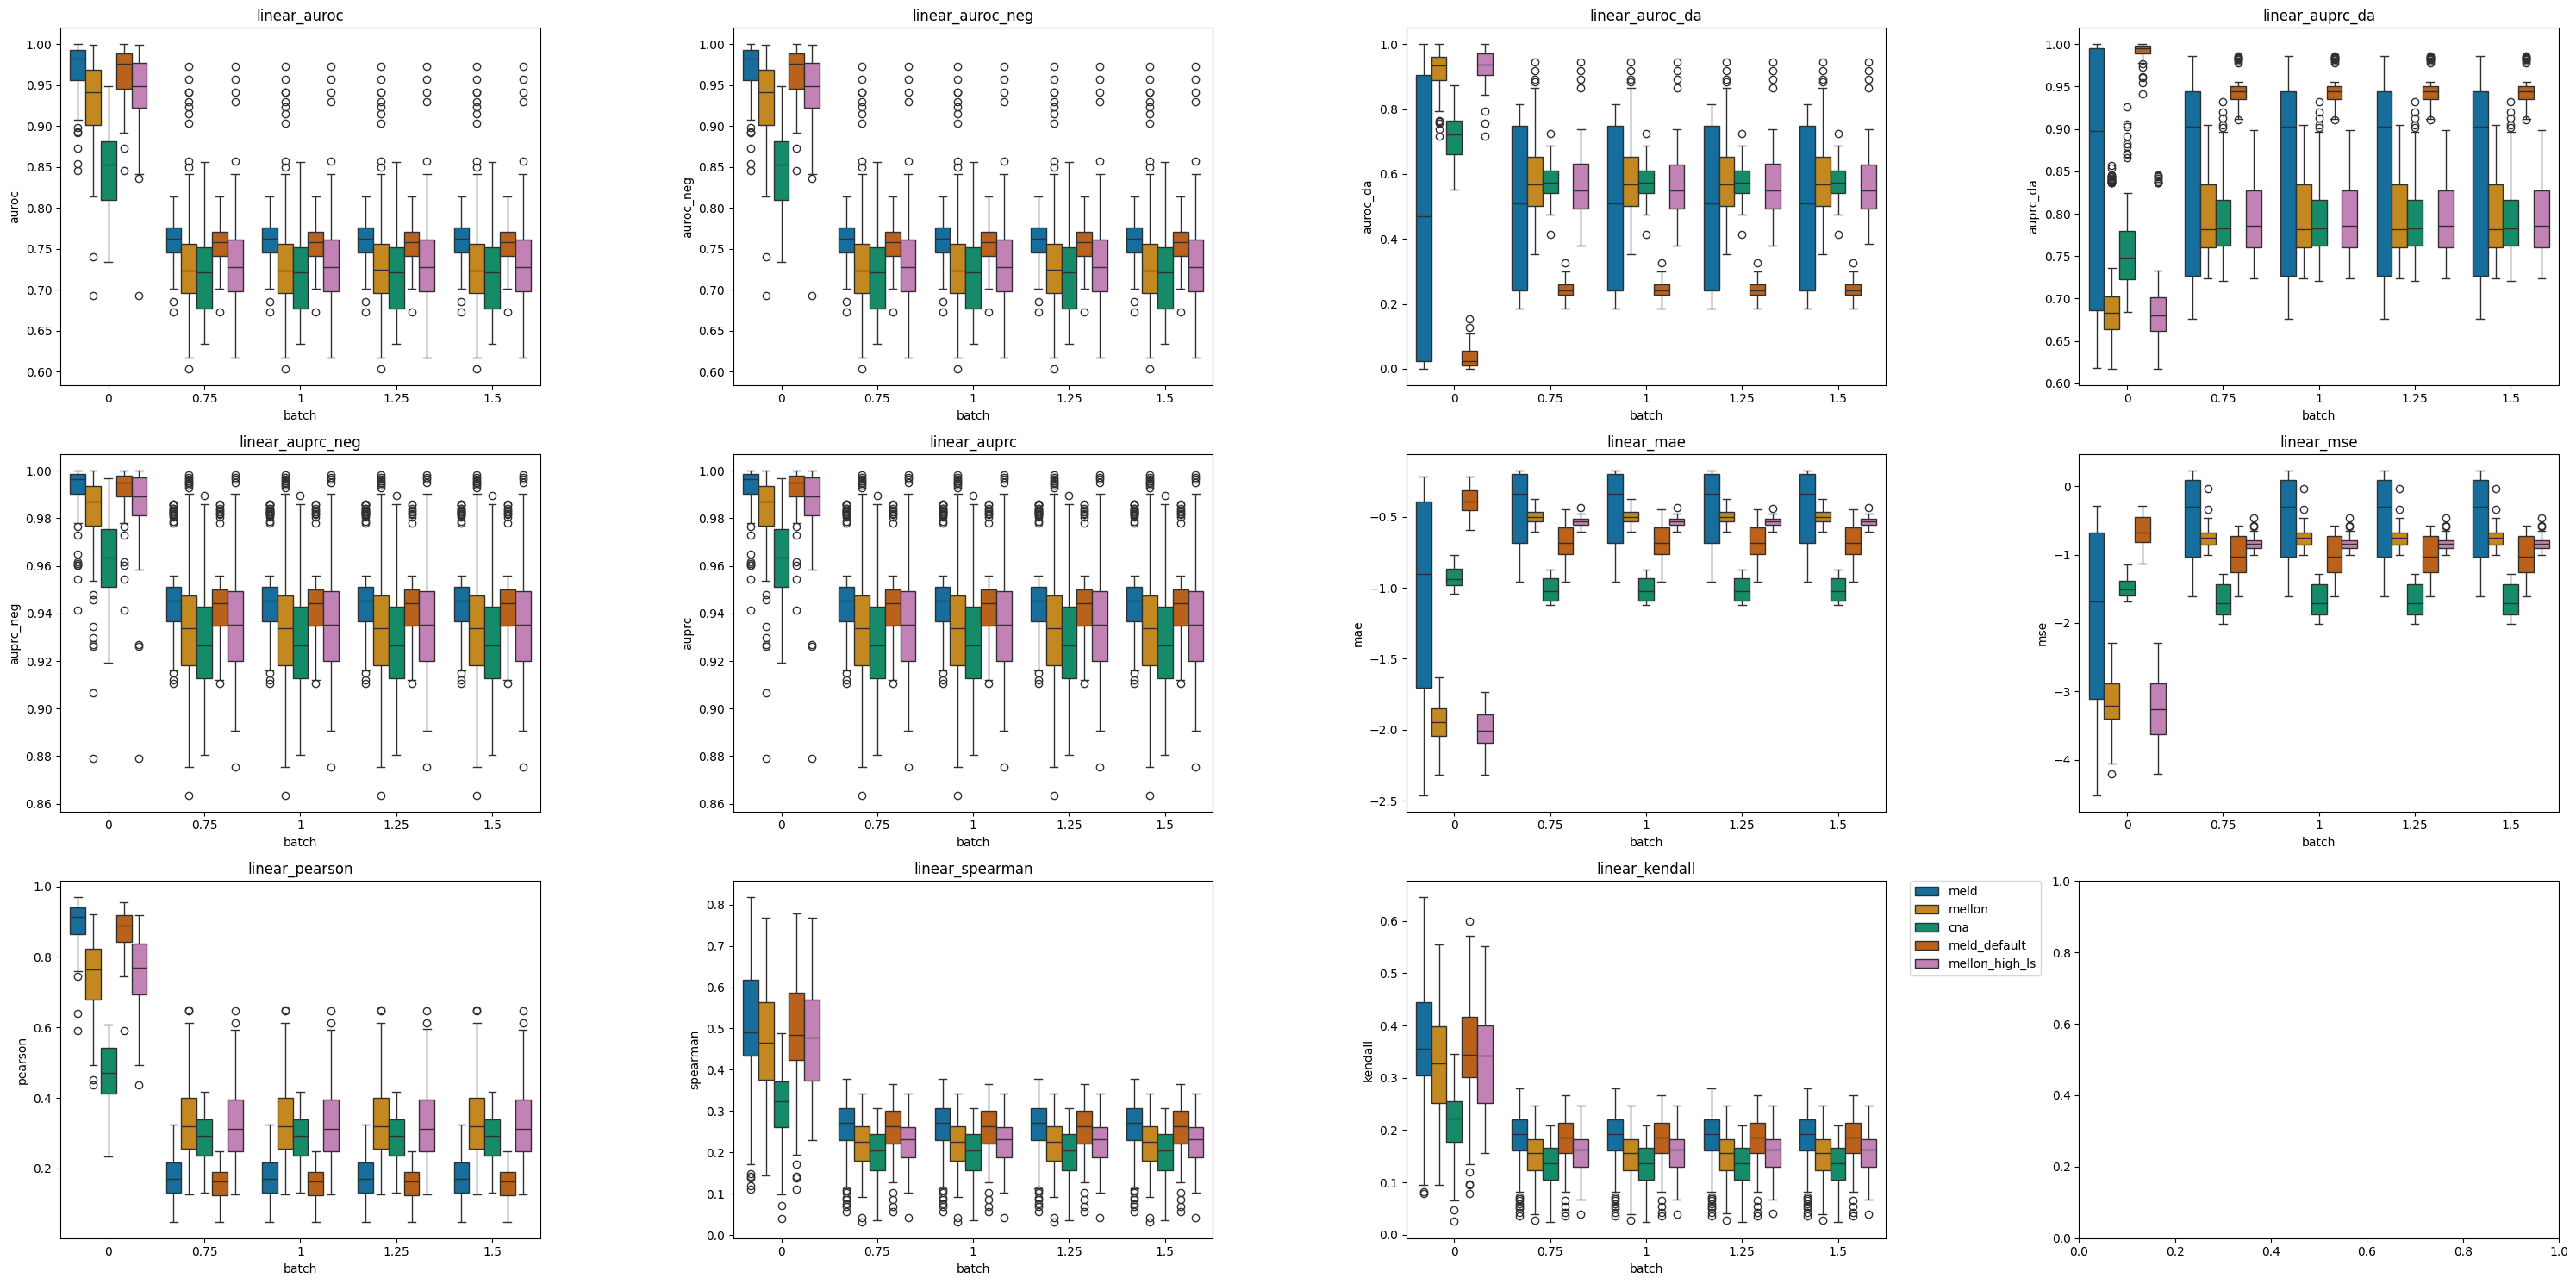

In [111]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

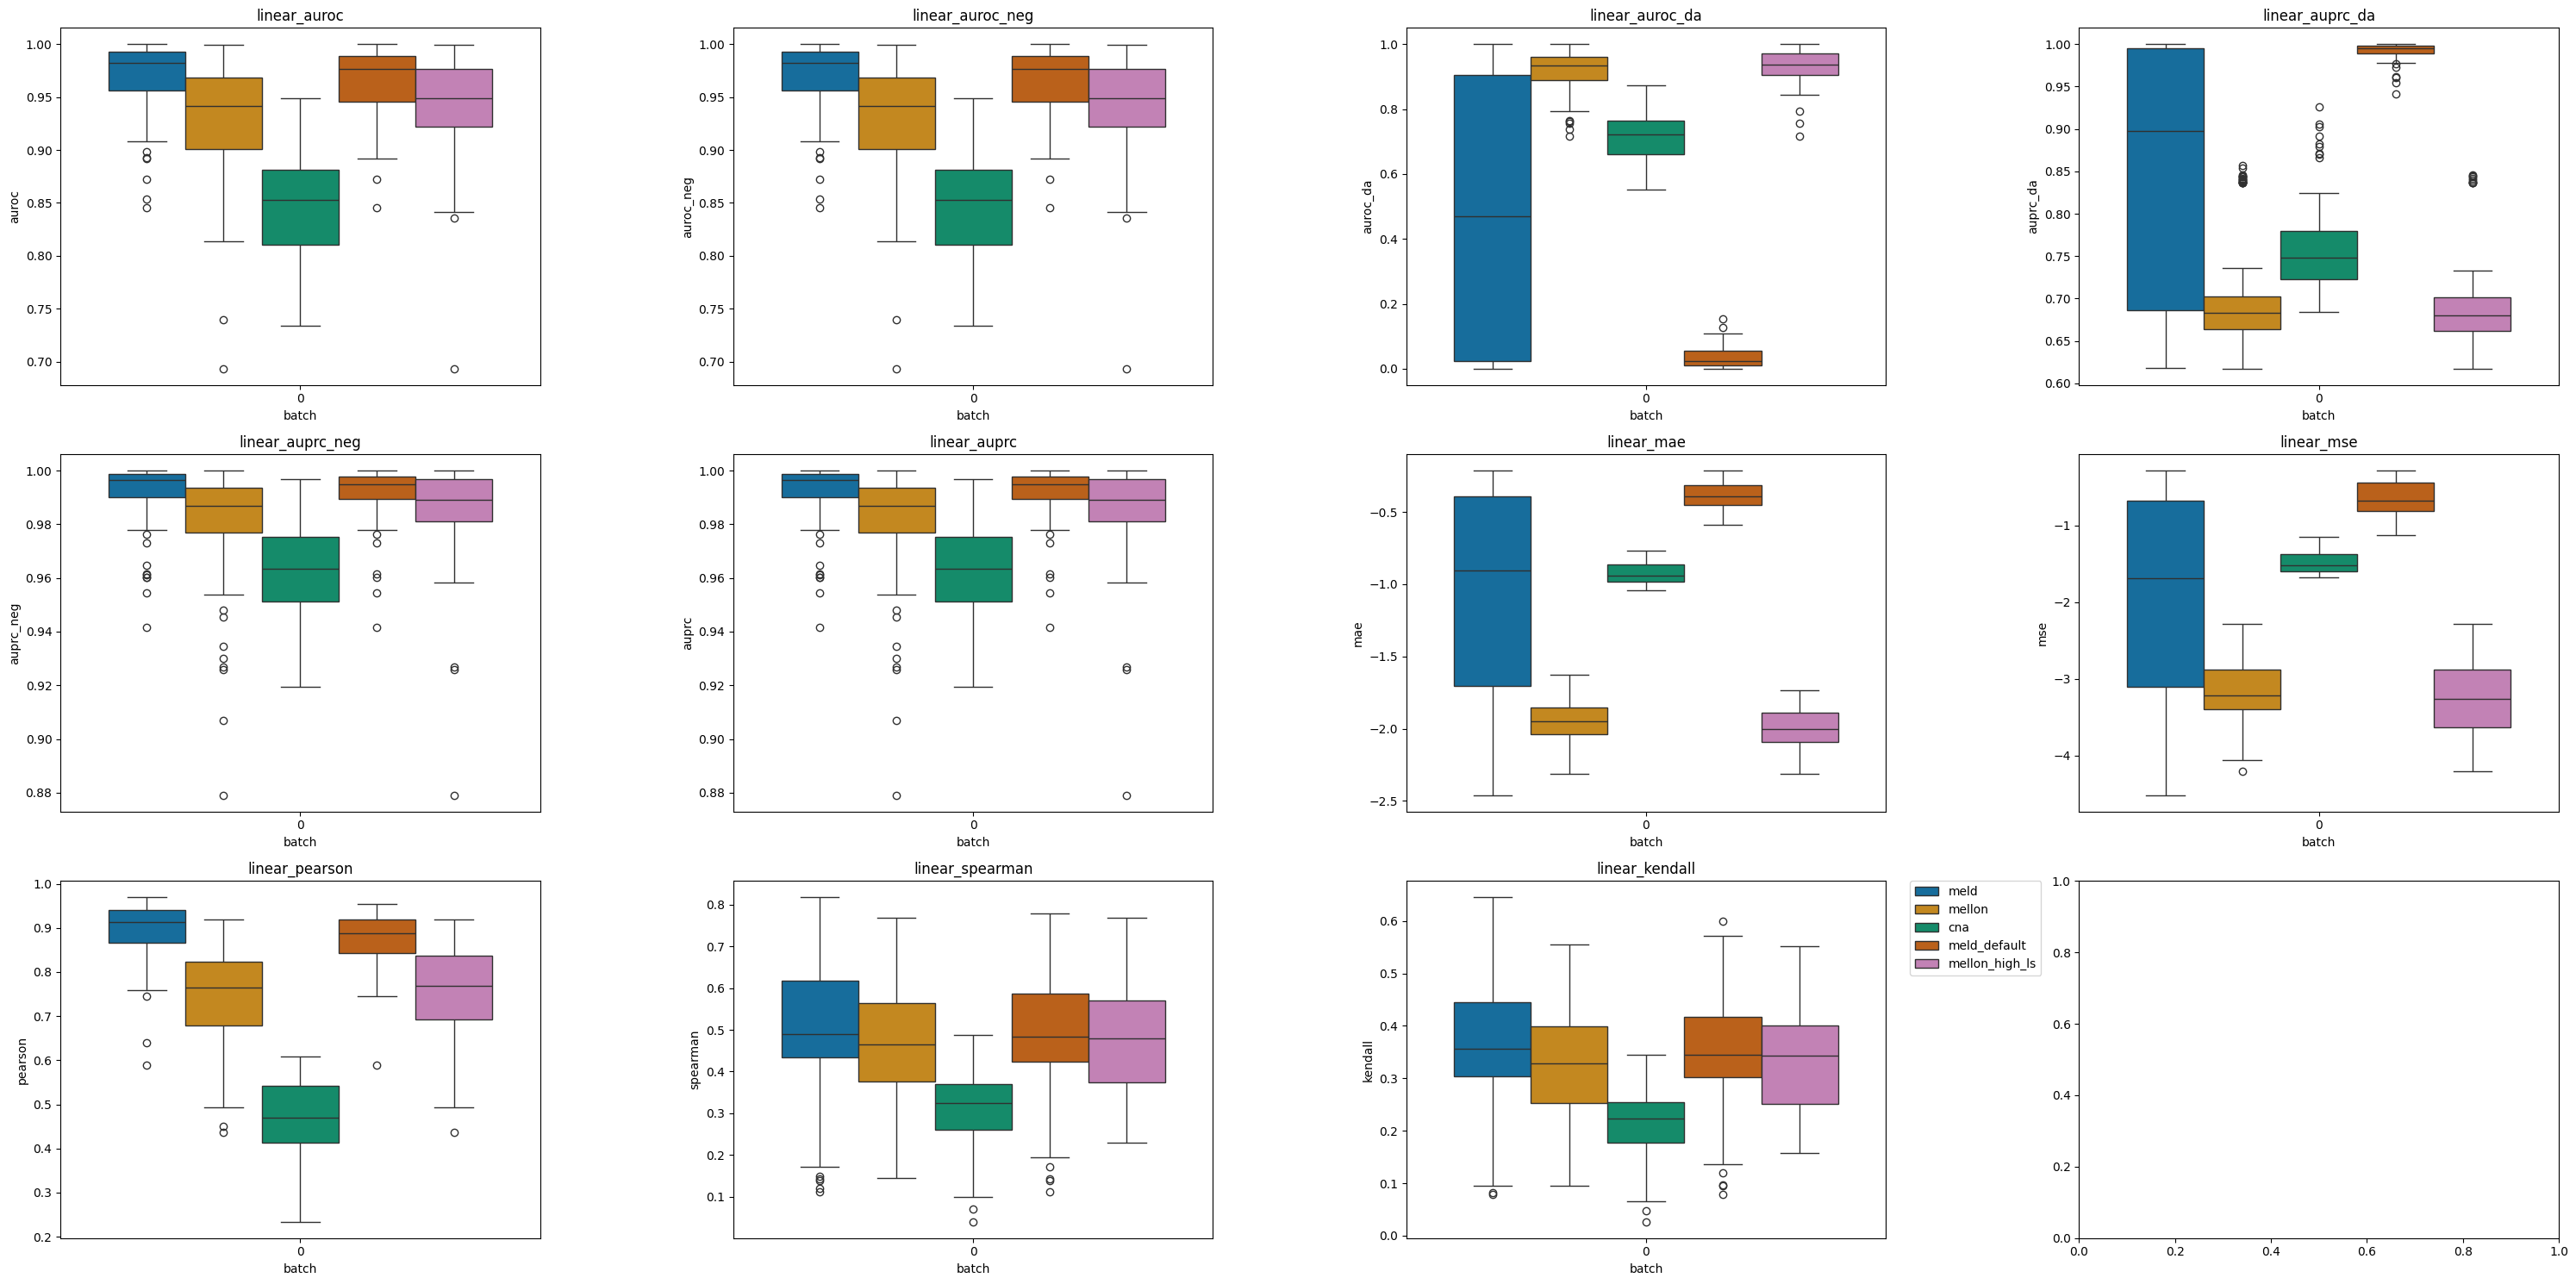

In [129]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

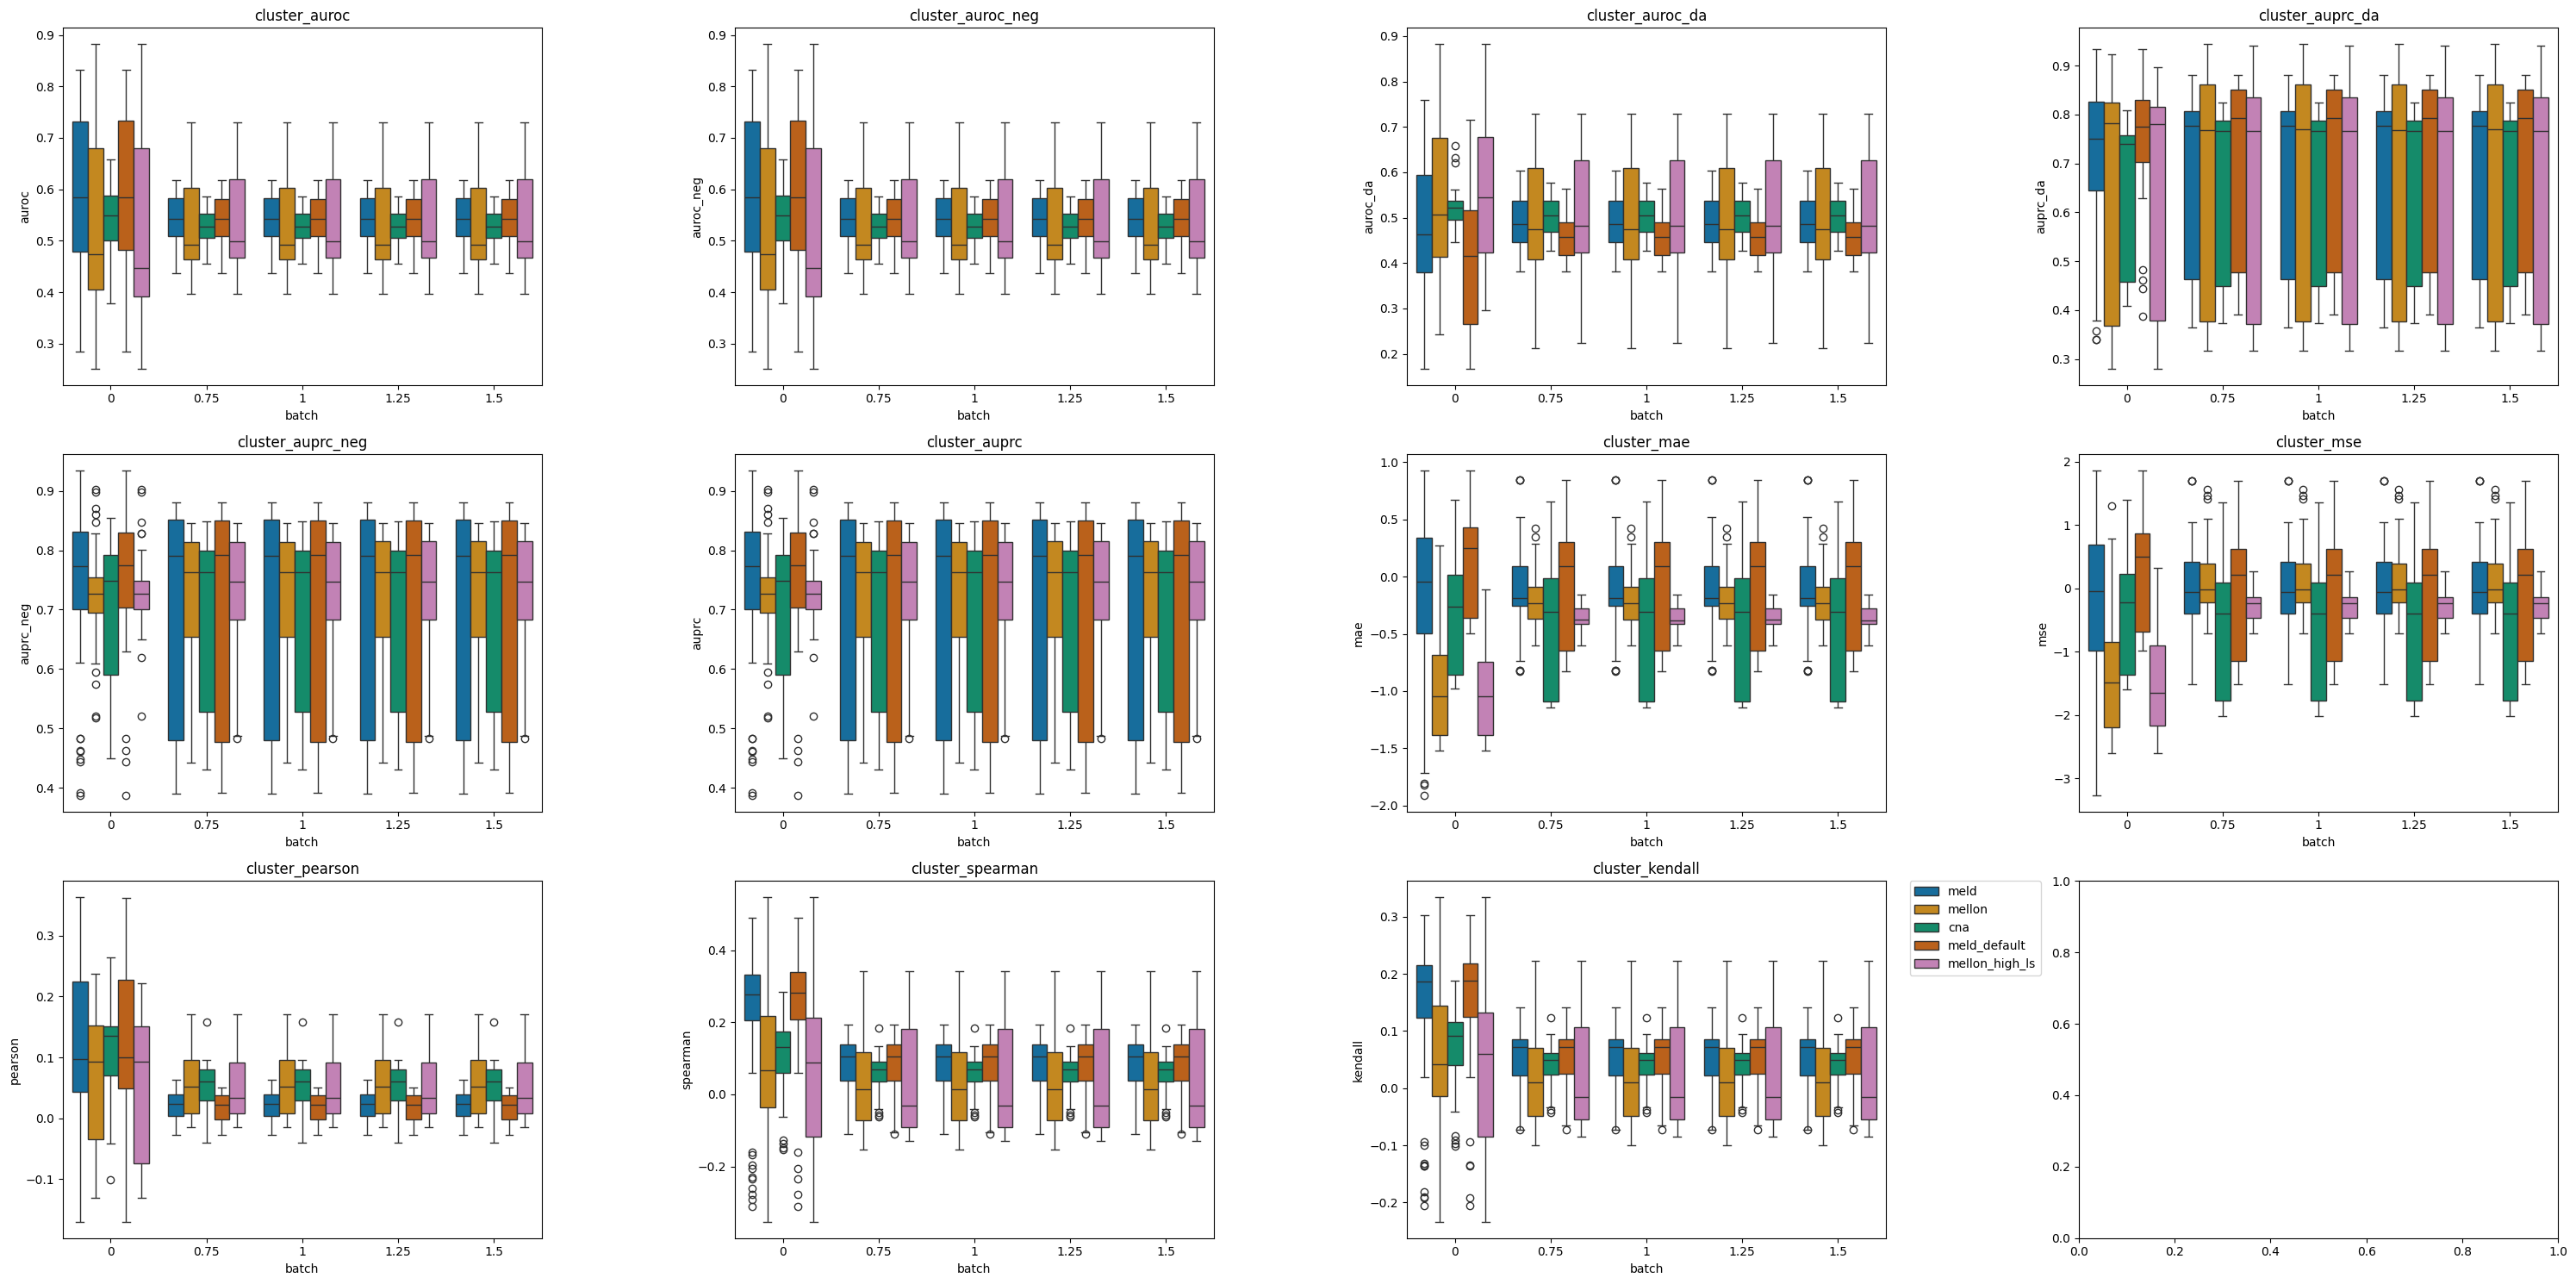

In [64]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

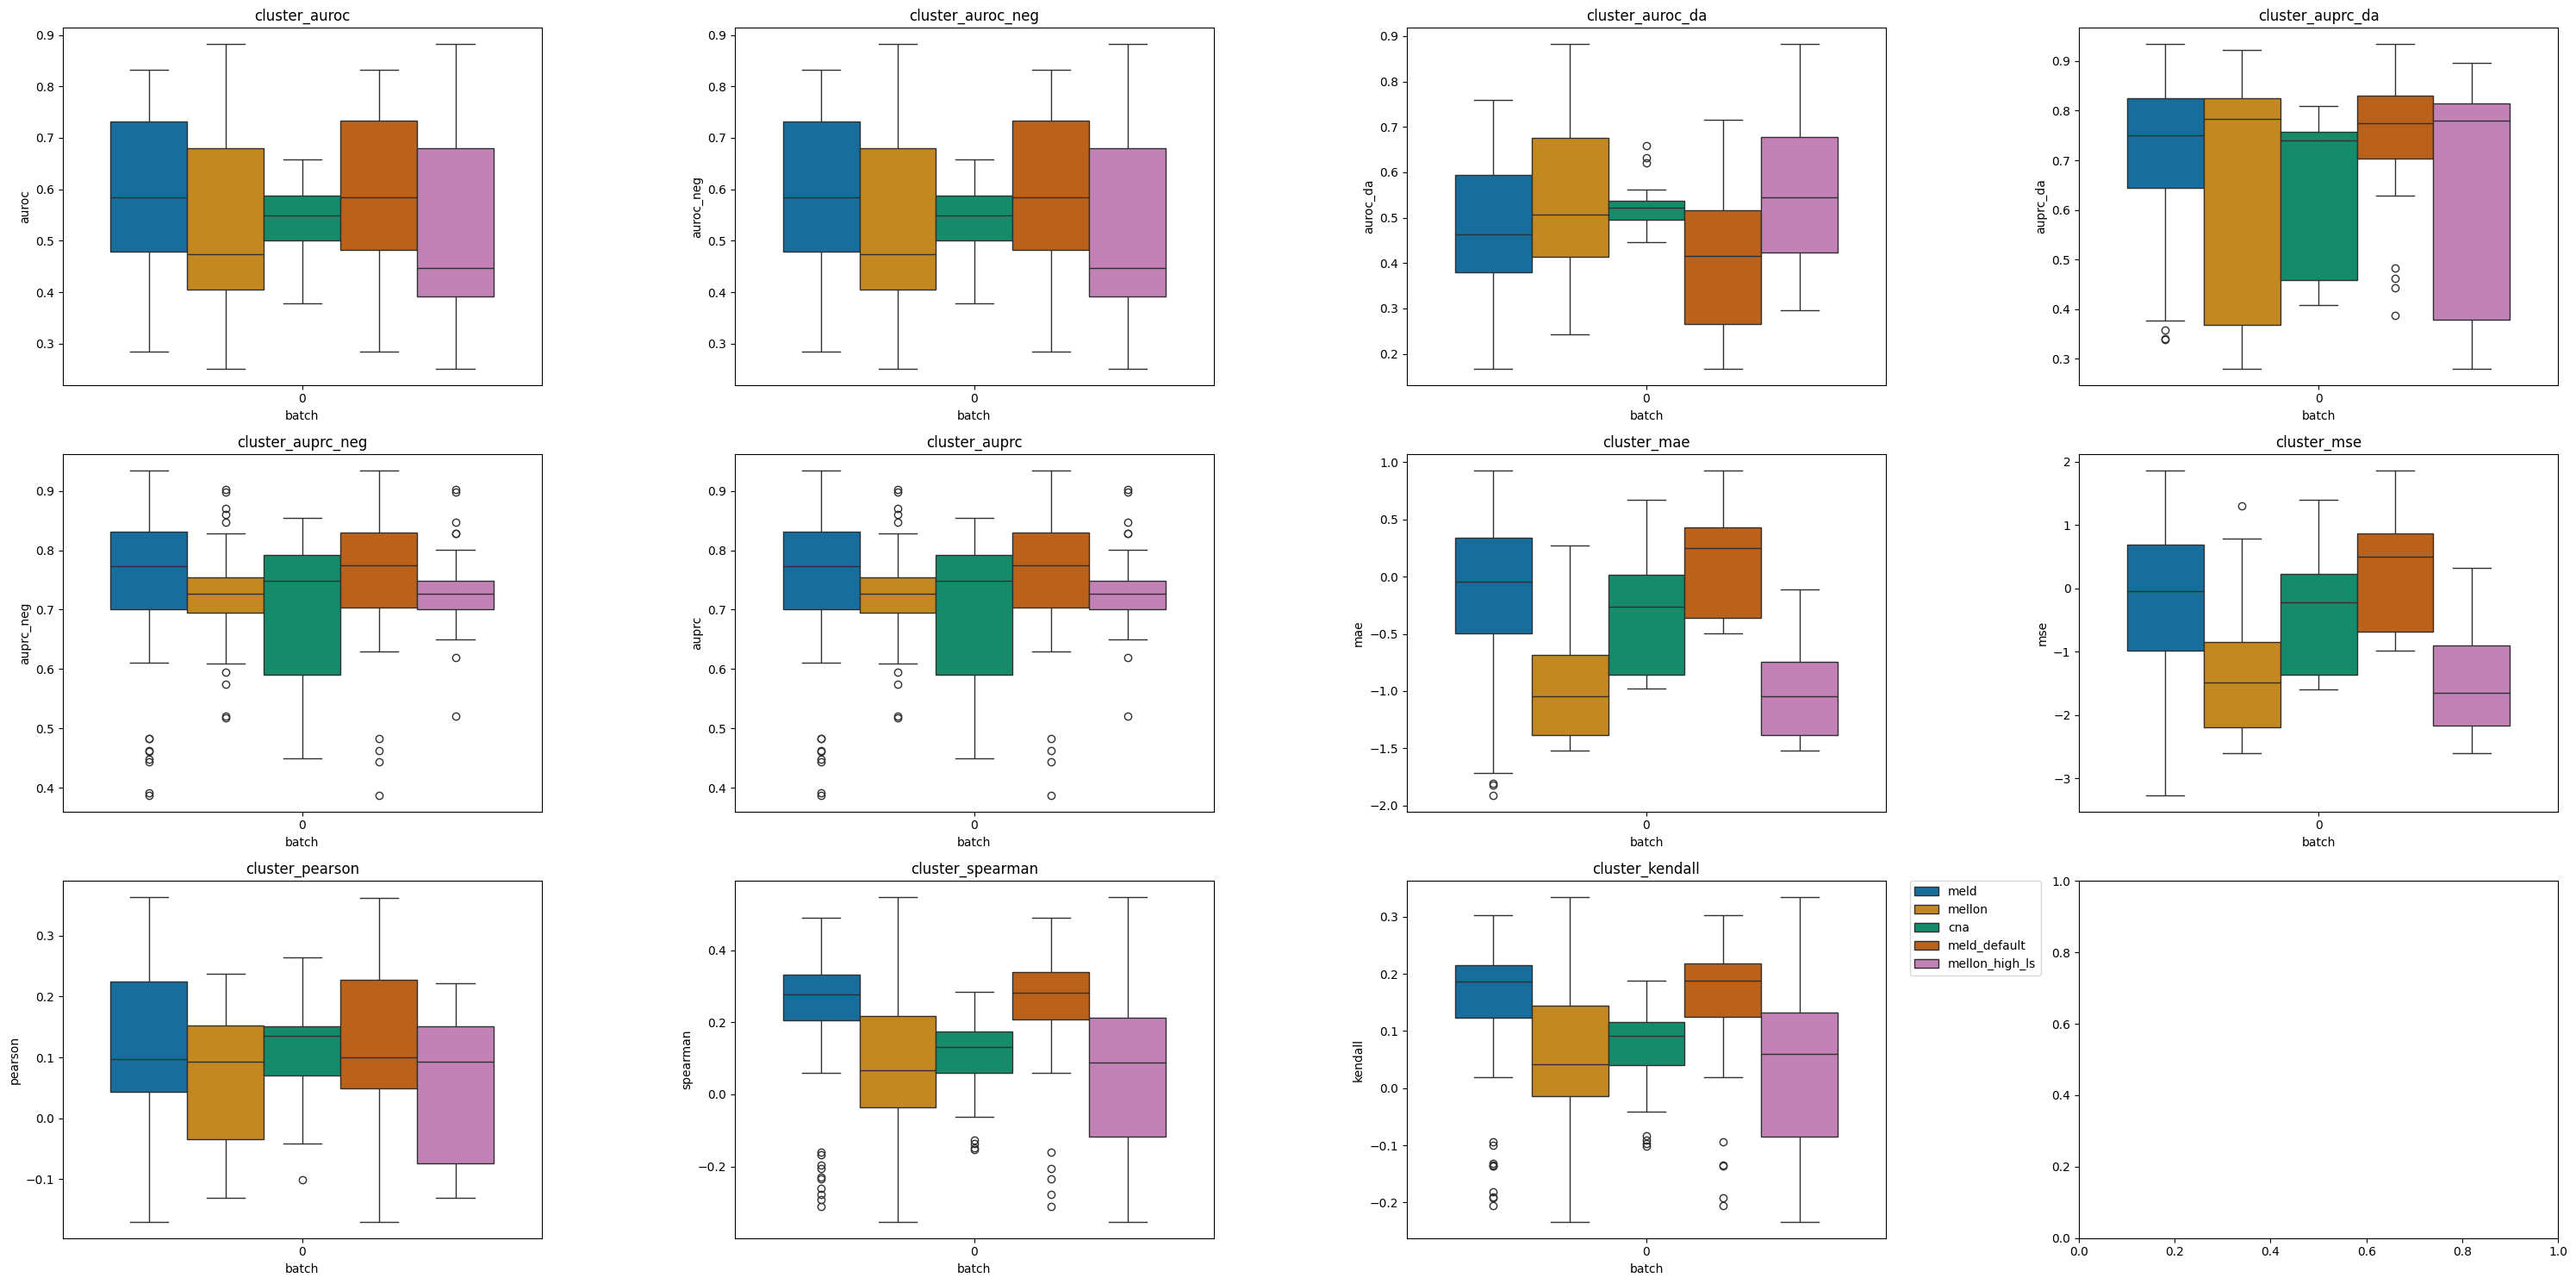

In [127]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/341716939.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

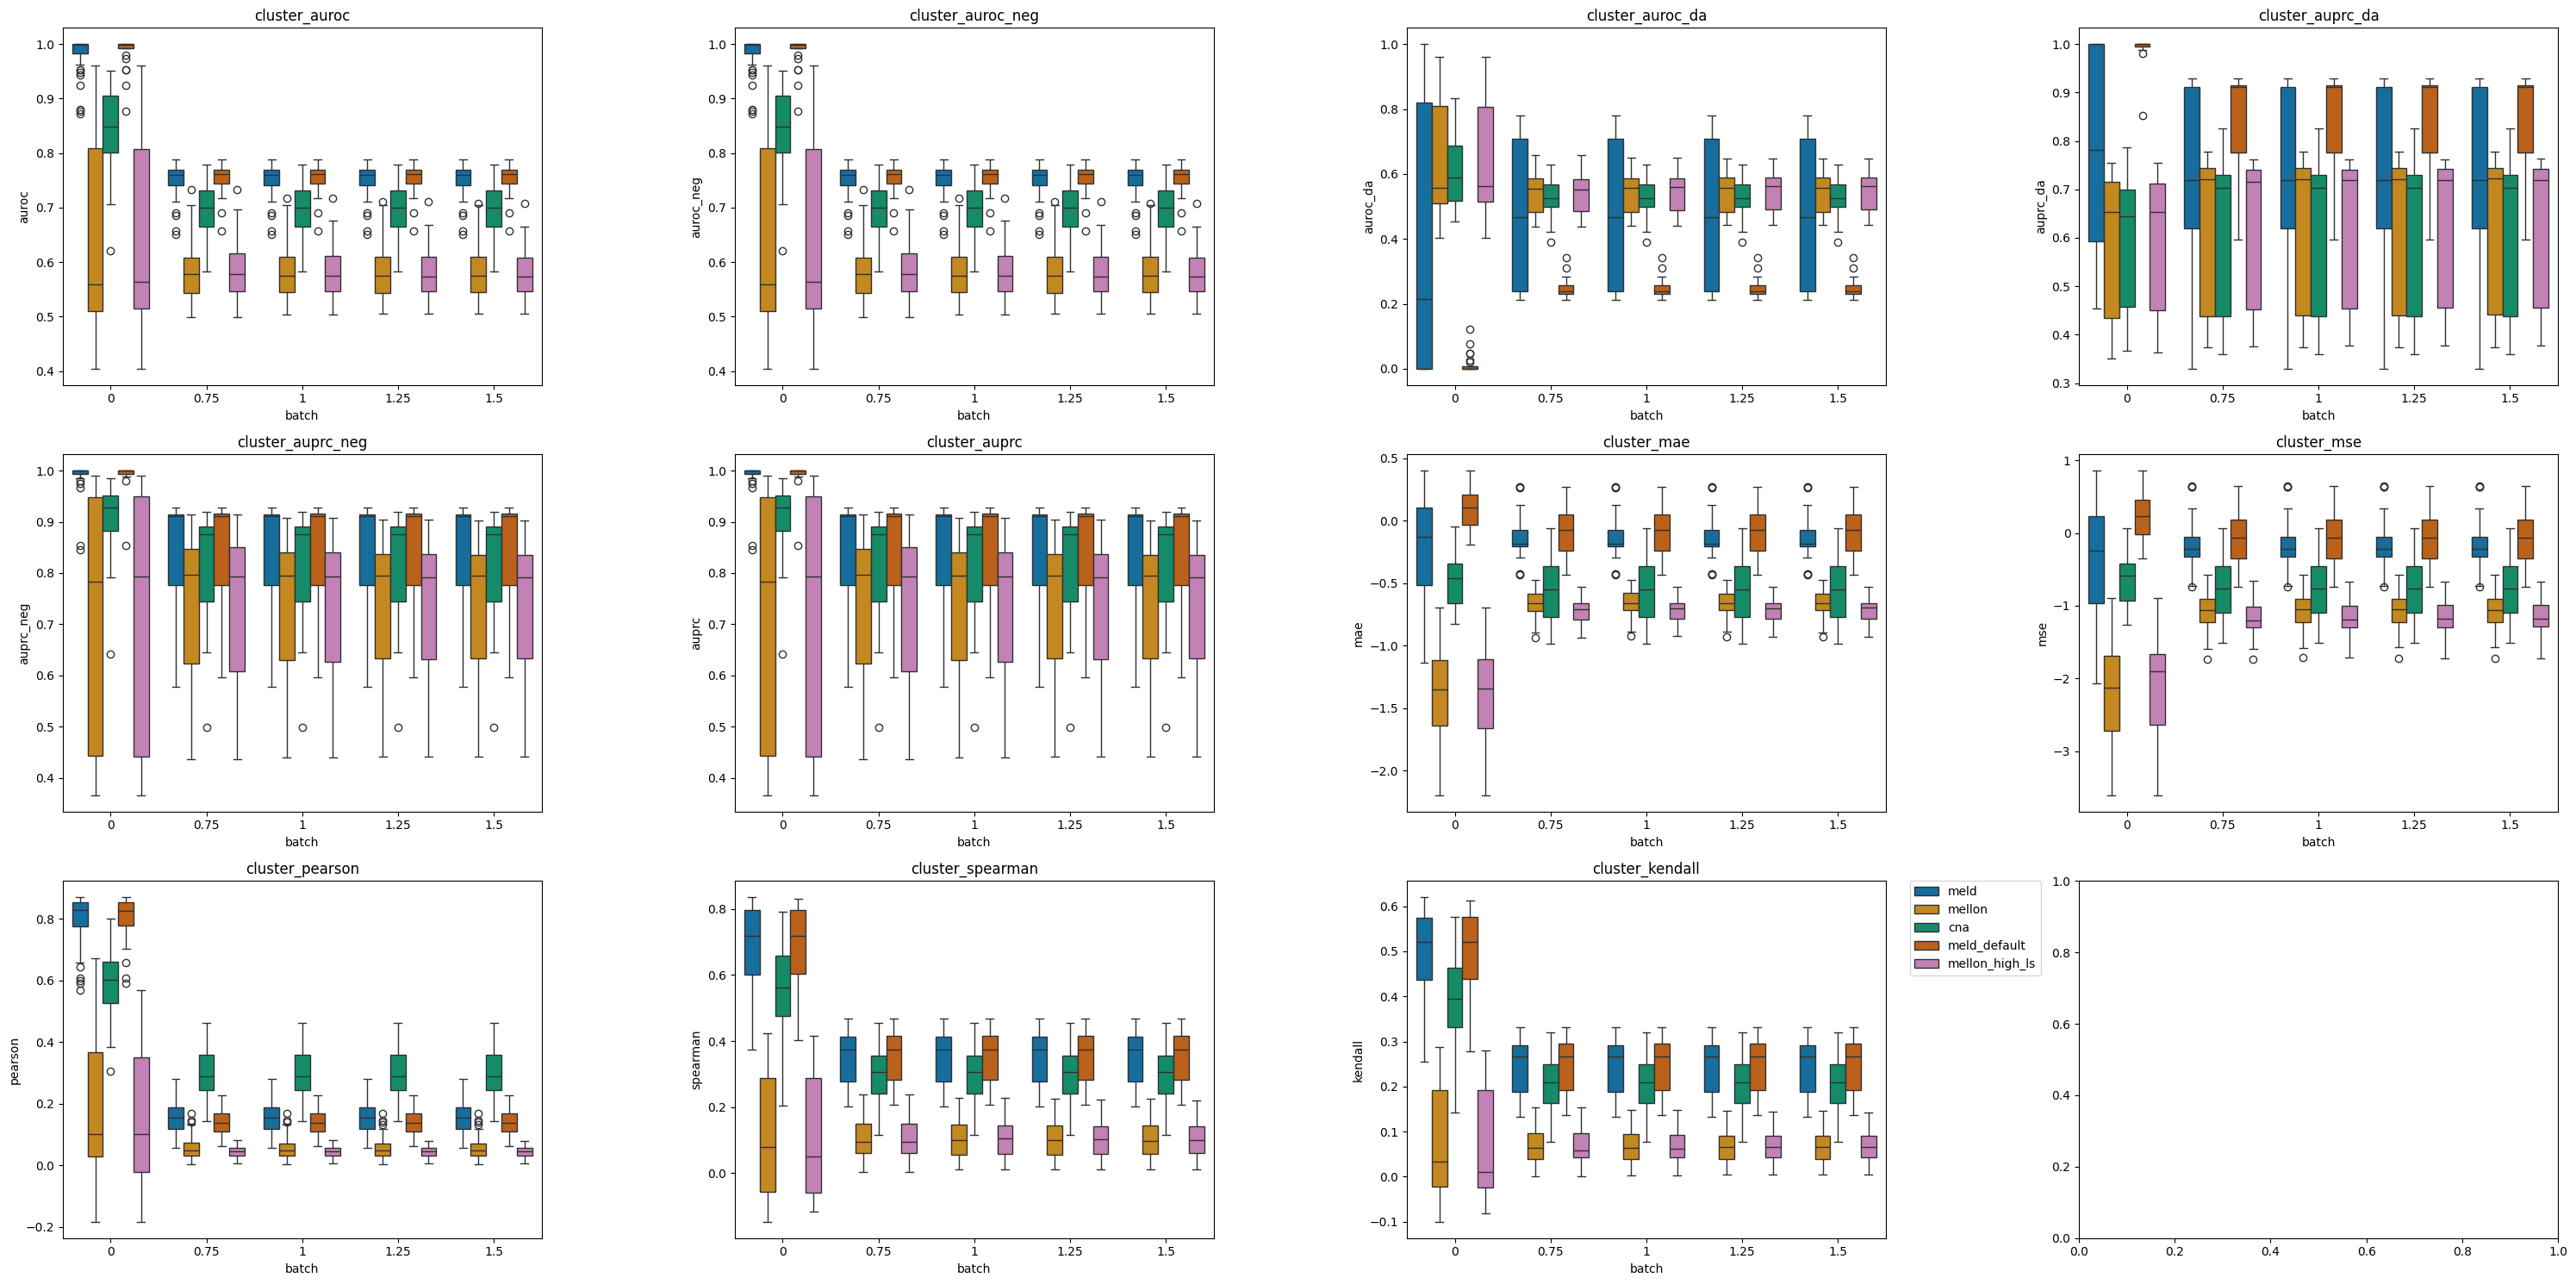

In [67]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

In [70]:
### dm = 30

In [153]:
ad = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/branch/branch_anndata_dm_10.h5ad")

In [154]:
performance_dict,ground_truth_dict = get_results("branch")

In [155]:
ground_truth_dict['0_43_M1_0.75']

,true_labels,Condition1_prob,Condition2_prob,synth_labels,lfc_truth
C1,NotDA,0.502888,0.497112,Condition1,-0.011554
C2,NotDA,0.504778,0.495222,Condition2,-0.019112
C3,NotDA,0.505824,0.494176,Condition1,-0.023298
C4,NotDA,0.503284,0.496716,Condition2,-0.013136
C5,NotDA,0.505876,0.494124,Condition1,-0.023507
...,...,...,...,...,...
C7496,NotDA,0.505033,0.494967,Condition2,-0.020131
C7497,NotDA,0.503177,0.496823,Condition1,-0.012707
C7498,NotDA,0.503109,0.496891,Condition1,-0.012437
C7499,NotDA,0.503071,0.496929,Condition2,-0.012285


In [156]:
ad.obs["ground_truth_0_43_M1_0.75"]= ground_truth_dict['0_43_M1_0.75']["lfc_truth"]
ad.obs["truth_labels_0_43_M1_0.75"]= ground_truth_dict['0_43_M1_0.75']["true_labels"]
ad.obs["predicted_mellon_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["mellon"]
ad.obs["predicted_meld_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["meld"]
ad.obs["predicted_mellon_highls_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["meld_default"]

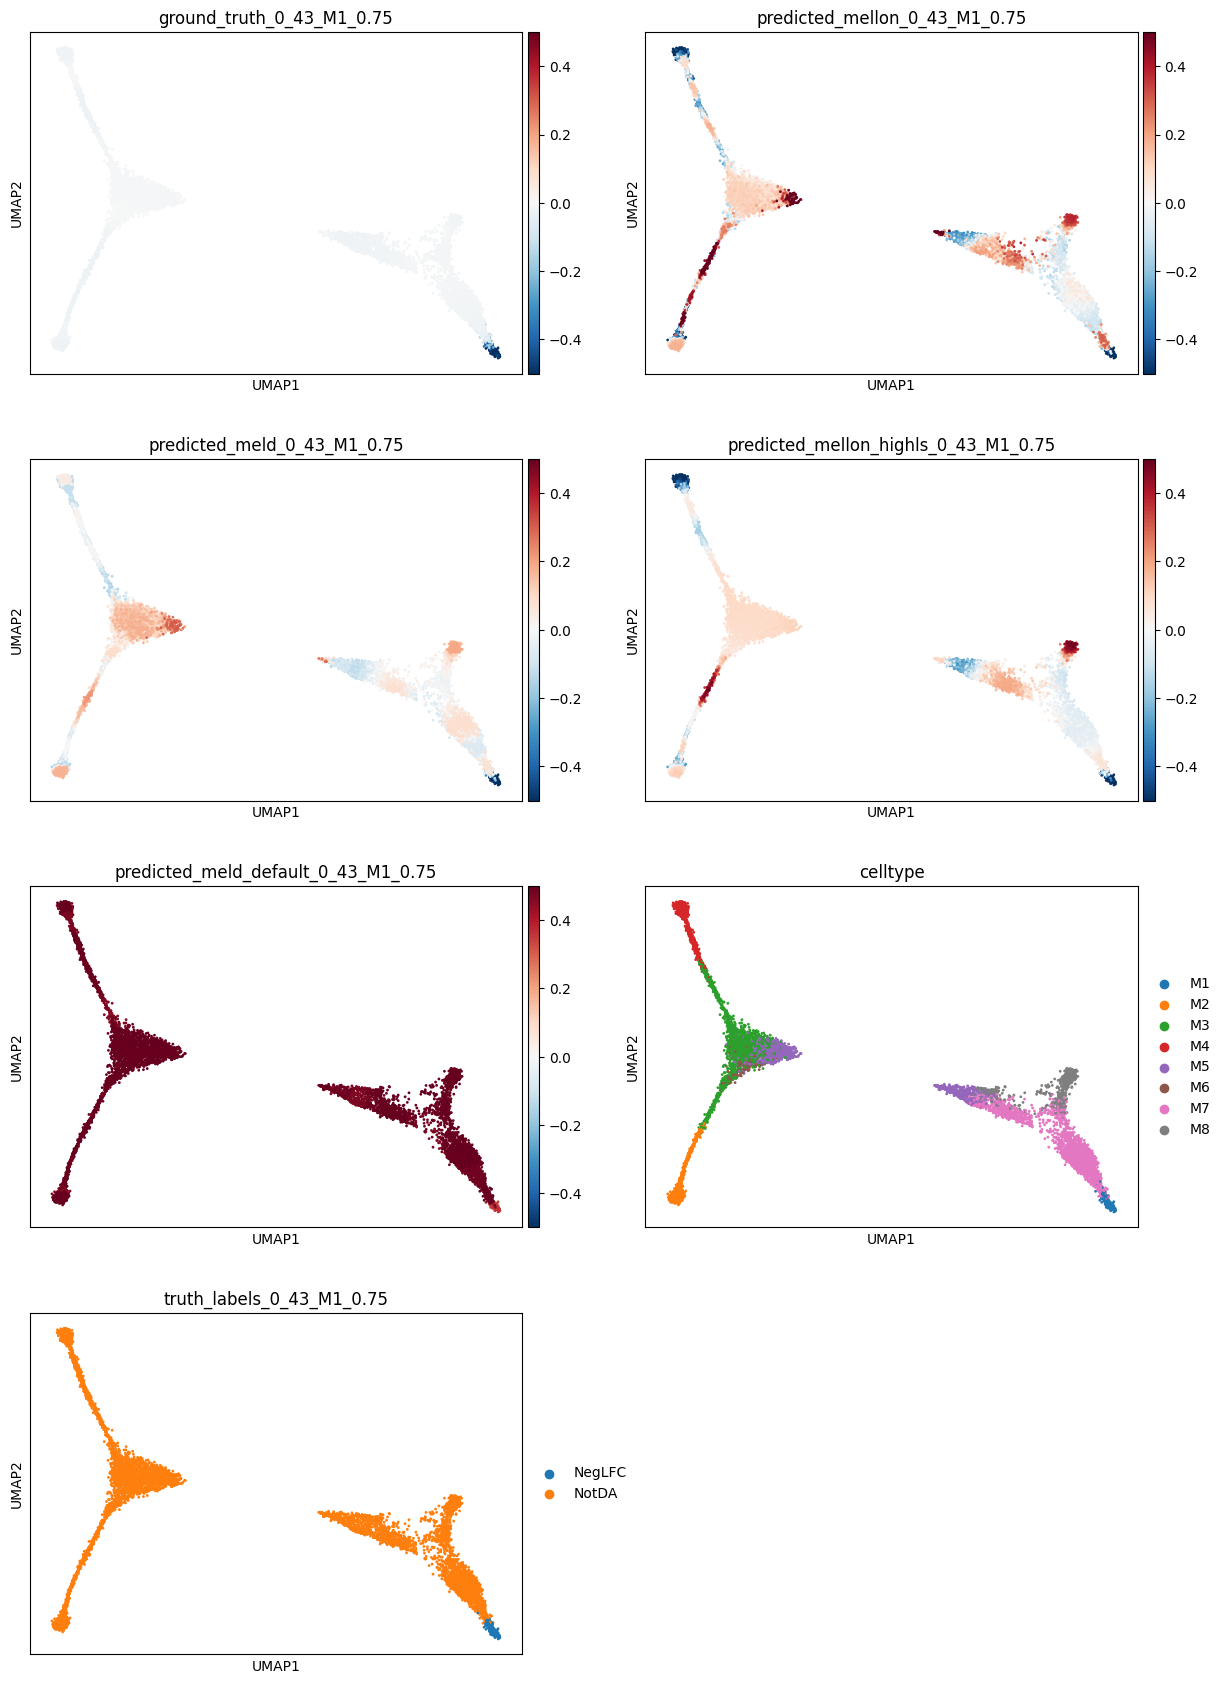

In [157]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M1_0.75","predicted_mellon_0_43_M1_0.75","predicted_meld_0_43_M1_0.75","predicted_mellon_highls_0_43_M1_0.75",
                                   "predicted_meld_default_0_43_M1_0.75","celltype","truth_labels_0_43_M1_0.75"], ncols = 2,cmap = "RdBu_r",vmax = 0.5,vmin = -0.5)

In [158]:
ad.obs["ground_truth_0_43_M3_0.75"]= ground_truth_dict['0_43_M3_0.75']["lfc_truth"]
ad.obs["truth_labels_0_43_M3_0.75"]= ground_truth_dict['0_43_M3_0.75']["true_labels"]
ad.obs["predicted_mellon_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["mellon"]
ad.obs["predicted_meld_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["meld"]
ad.obs["predicted_mellon_highls_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["meld_default"]

(array([3.000e+00, 3.100e+01, 9.000e+01, 1.700e+02, 3.080e+02, 1.022e+03,
        5.060e+02, 1.223e+03, 3.665e+03, 4.820e+02]),
 array([-1.09861229, -0.98875106, -0.87888983, -0.7690286 , -0.65916737,
        -0.54930614, -0.43944492, -0.32958369, -0.21972246, -0.10986123,
         0.        ]),
 <BarContainer object of 10 artists>)

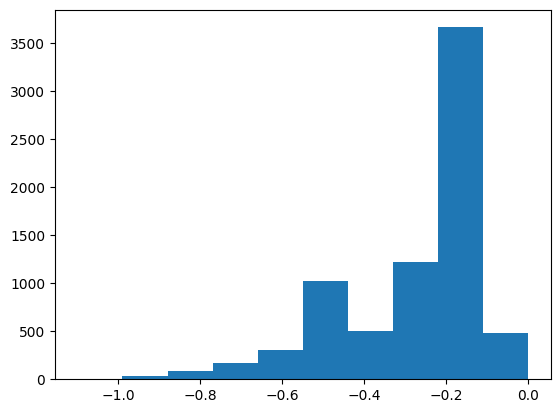

In [188]:
plt.hist(ground_truth_dict['0_43_M3_0.75']["lfc_truth"])

In [163]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

0.11573672082767923

In [182]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

0.2805347859146312

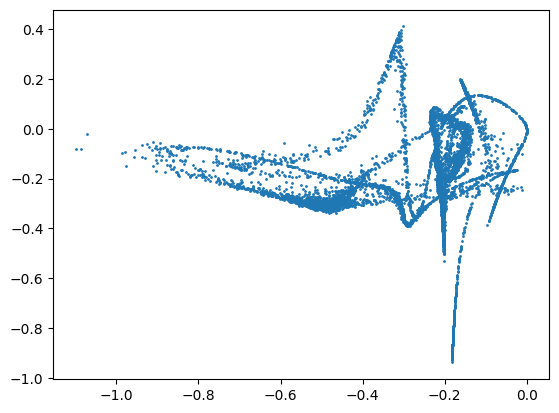

In [185]:
plt.scatter(ground_truth_dict['0_43_M3_0.75']["lfc_truth"], performance_dict['0_43_M3_0.75']["mellon_high_ls"], s=1)

In [164]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

0.7326143666305618

In [179]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

0.7032910800999624

In [165]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

0.7597730616242953

In [180]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

0.7554246733454469

In [200]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

{'mean_auroc': 0.9529281886052718,
 'da_auroc': 0.7598393666101999,
 'neg_auroc': 0.9529281886052718,
 'pos_auroc': nan}

In [199]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

{'mean_auroc': 0.9412714998652497,
 'da_auroc': 0.05872850013475014,
 'neg_auroc': 0.9412714998652497,
 'pos_auroc': nan}

In [198]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

{'mean_auroc': 0.7082167303521469,
 'da_auroc': 0.6844035541952207,
 'neg_auroc': 0.7082167303521469,
 'pos_auroc': nan}

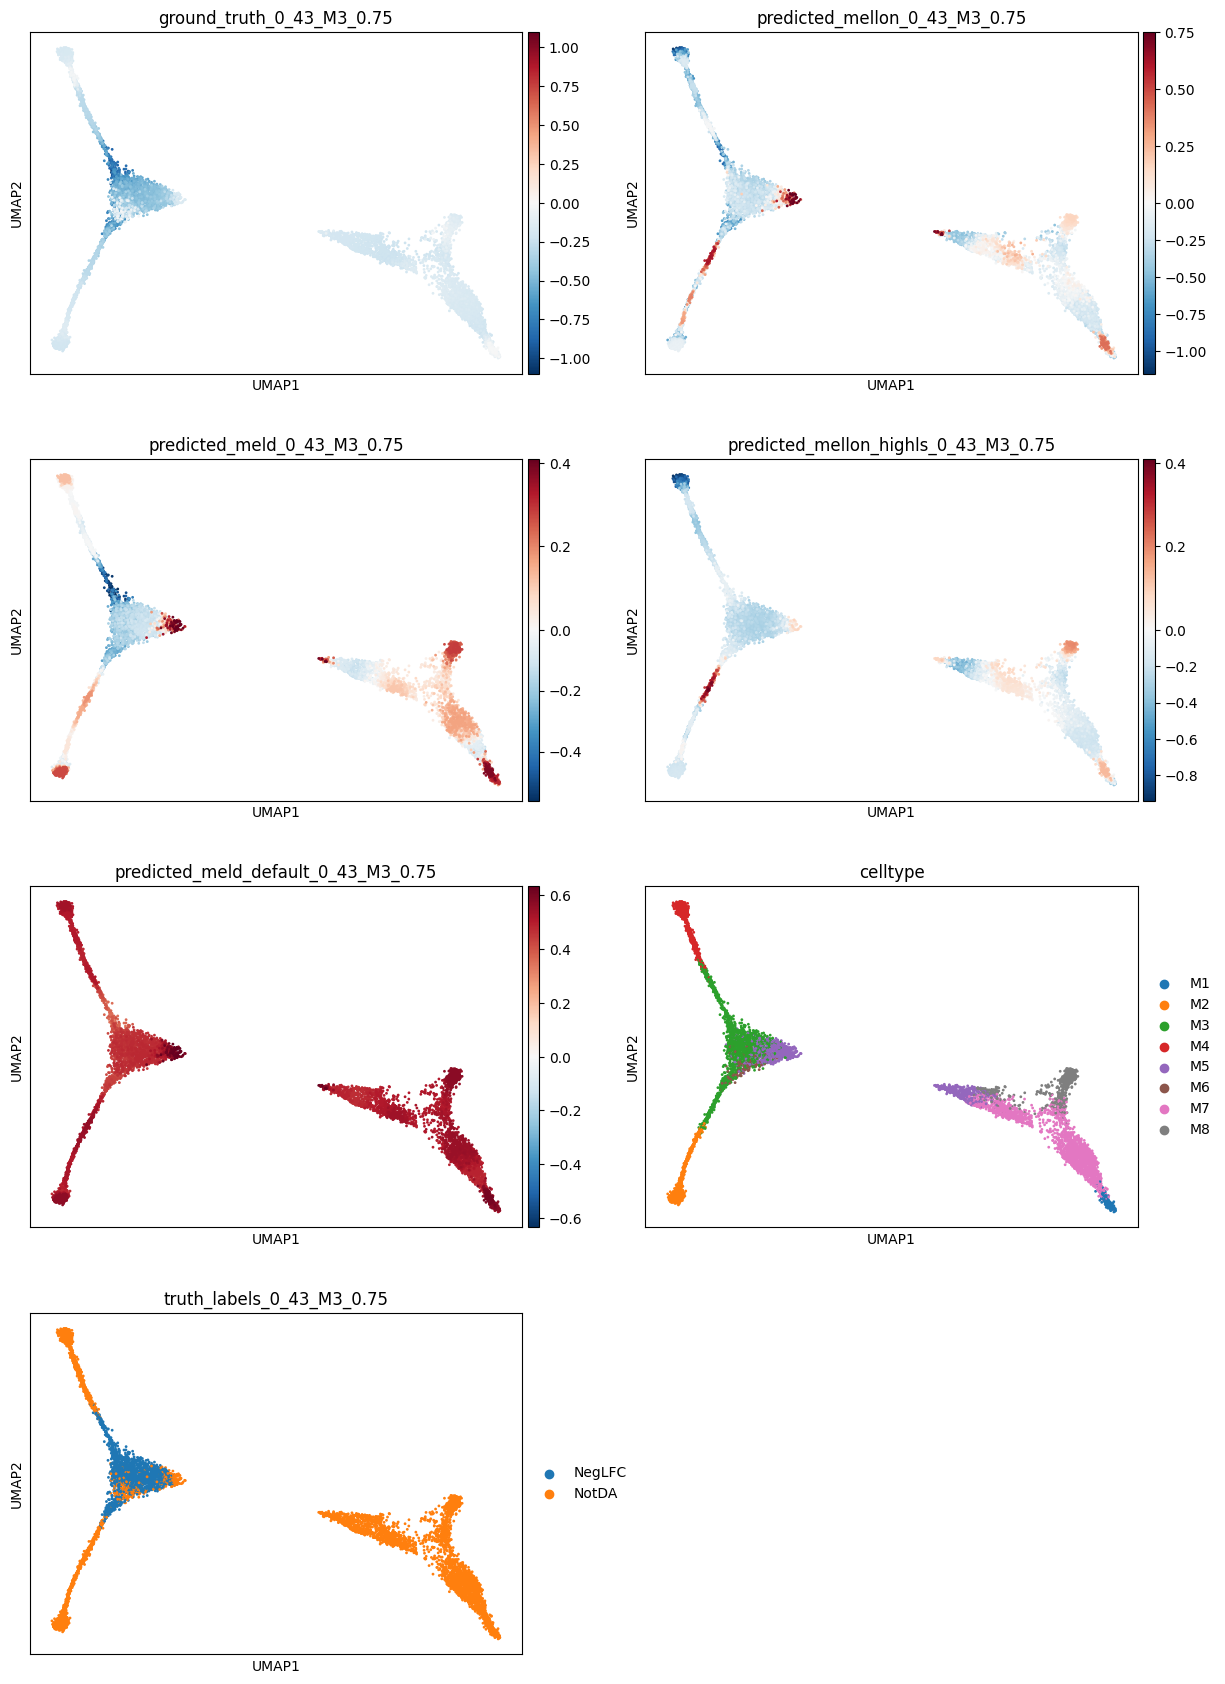

In [186]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M3_0.75","predicted_mellon_0_43_M3_0.75","predicted_meld_0_43_M3_0.75","predicted_mellon_highls_0_43_M3_0.75",
                                   "predicted_meld_default_0_43_M3_0.75","celltype","truth_labels_0_43_M3_0.75"], ncols = 2,cmap = "RdBu_r", vcenter=0)

In [160]:
ad.obs["ground_truth_0_43_M5_0.95"]= ground_truth_dict['0_43_M5_0.95']["lfc_truth"]
ad.obs["truth_labels_0_43_M5_0.95"]= ground_truth_dict['0_43_M5_0.95']["true_labels"]
ad.obs["predicted_mellon_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["mellon"]
ad.obs["predicted_meld_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["meld"]
ad.obs["predicted_mellon_highls_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["meld_default"]

In [167]:
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"mellon_high_ls"))
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld_default"))
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld"))

0.20779938723503247
0.8743889698847422
0.8942795993955859


In [168]:
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"mellon_high_ls"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld_default"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld"))

0.38129307646032135
0.704747884898629
0.7433644255175897


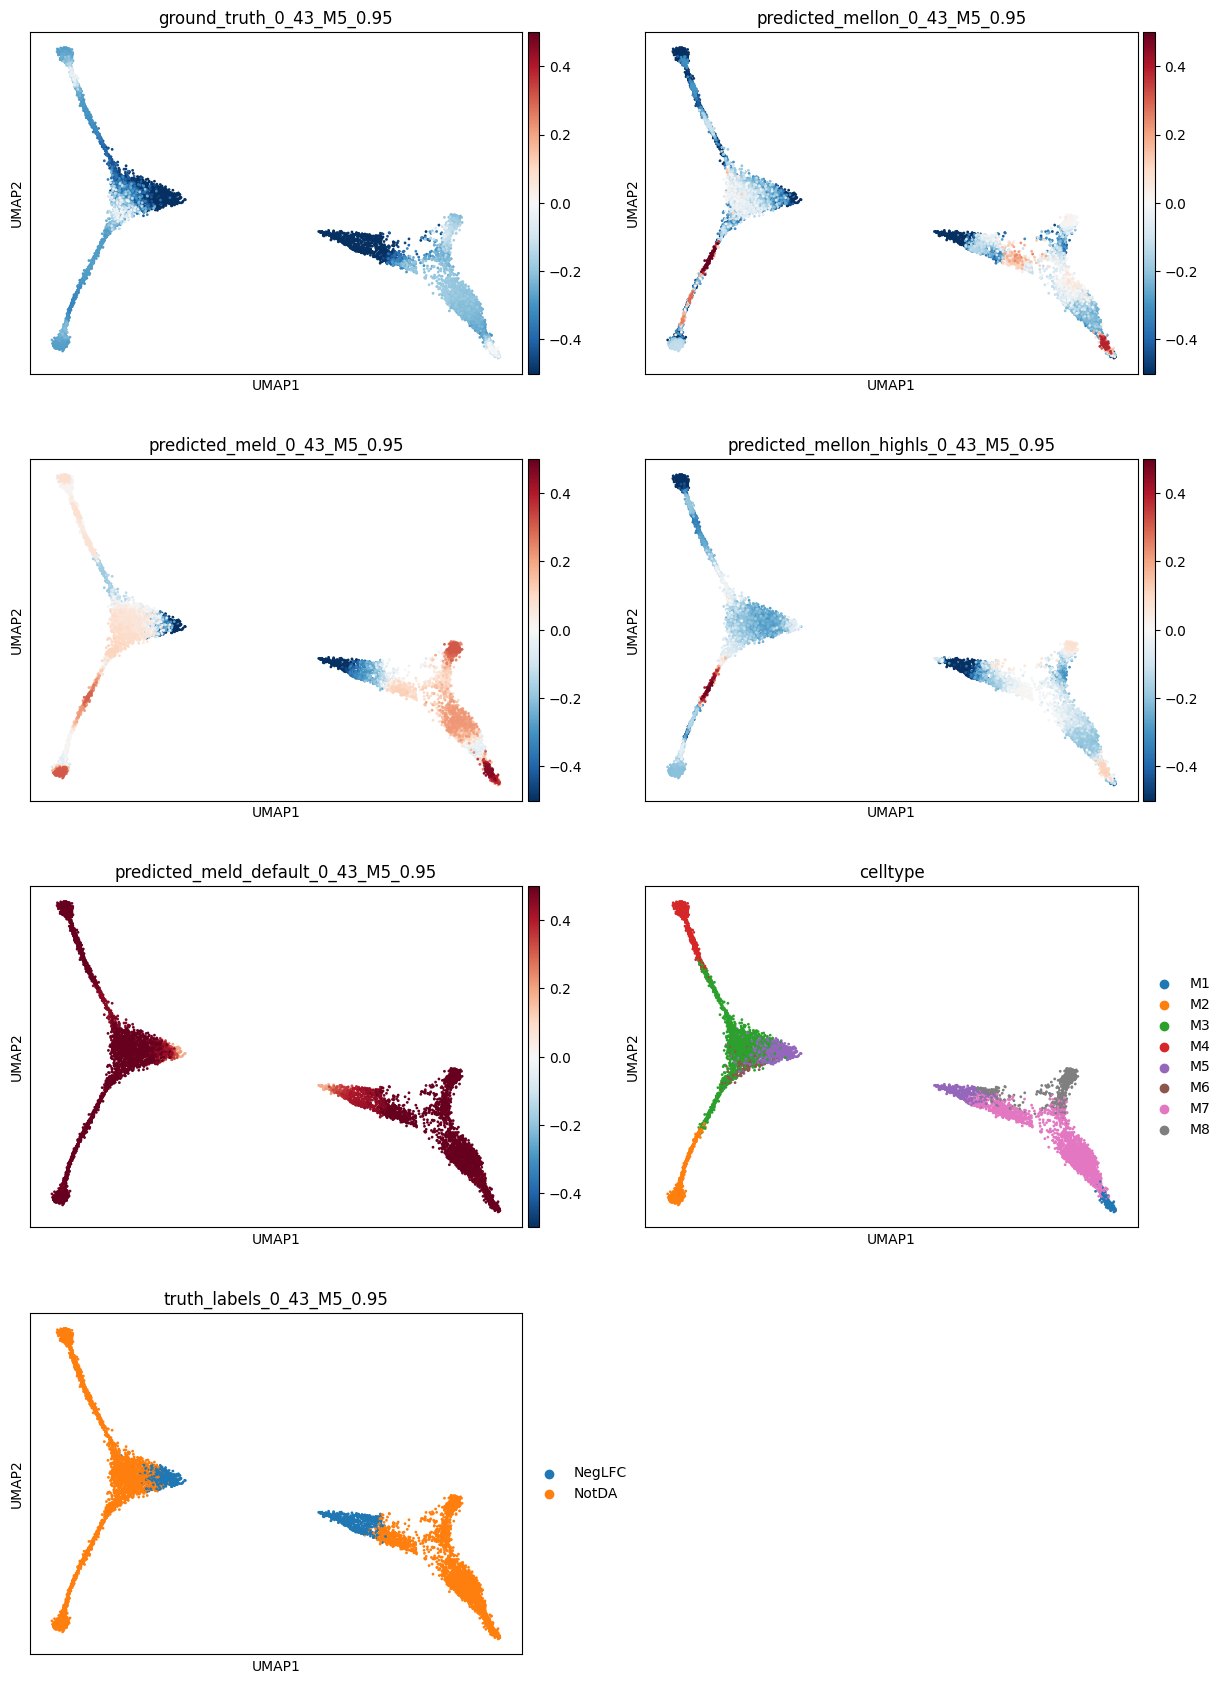

In [161]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M5_0.95","predicted_mellon_0_43_M5_0.95","predicted_meld_0_43_M5_0.95","predicted_mellon_highls_0_43_M5_0.95",
                                   "predicted_meld_default_0_43_M5_0.95","celltype","truth_labels_0_43_M5_0.95"], ncols = 2,cmap = "RdBu_r",vmax = 0.5,vmin = -0.5)

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

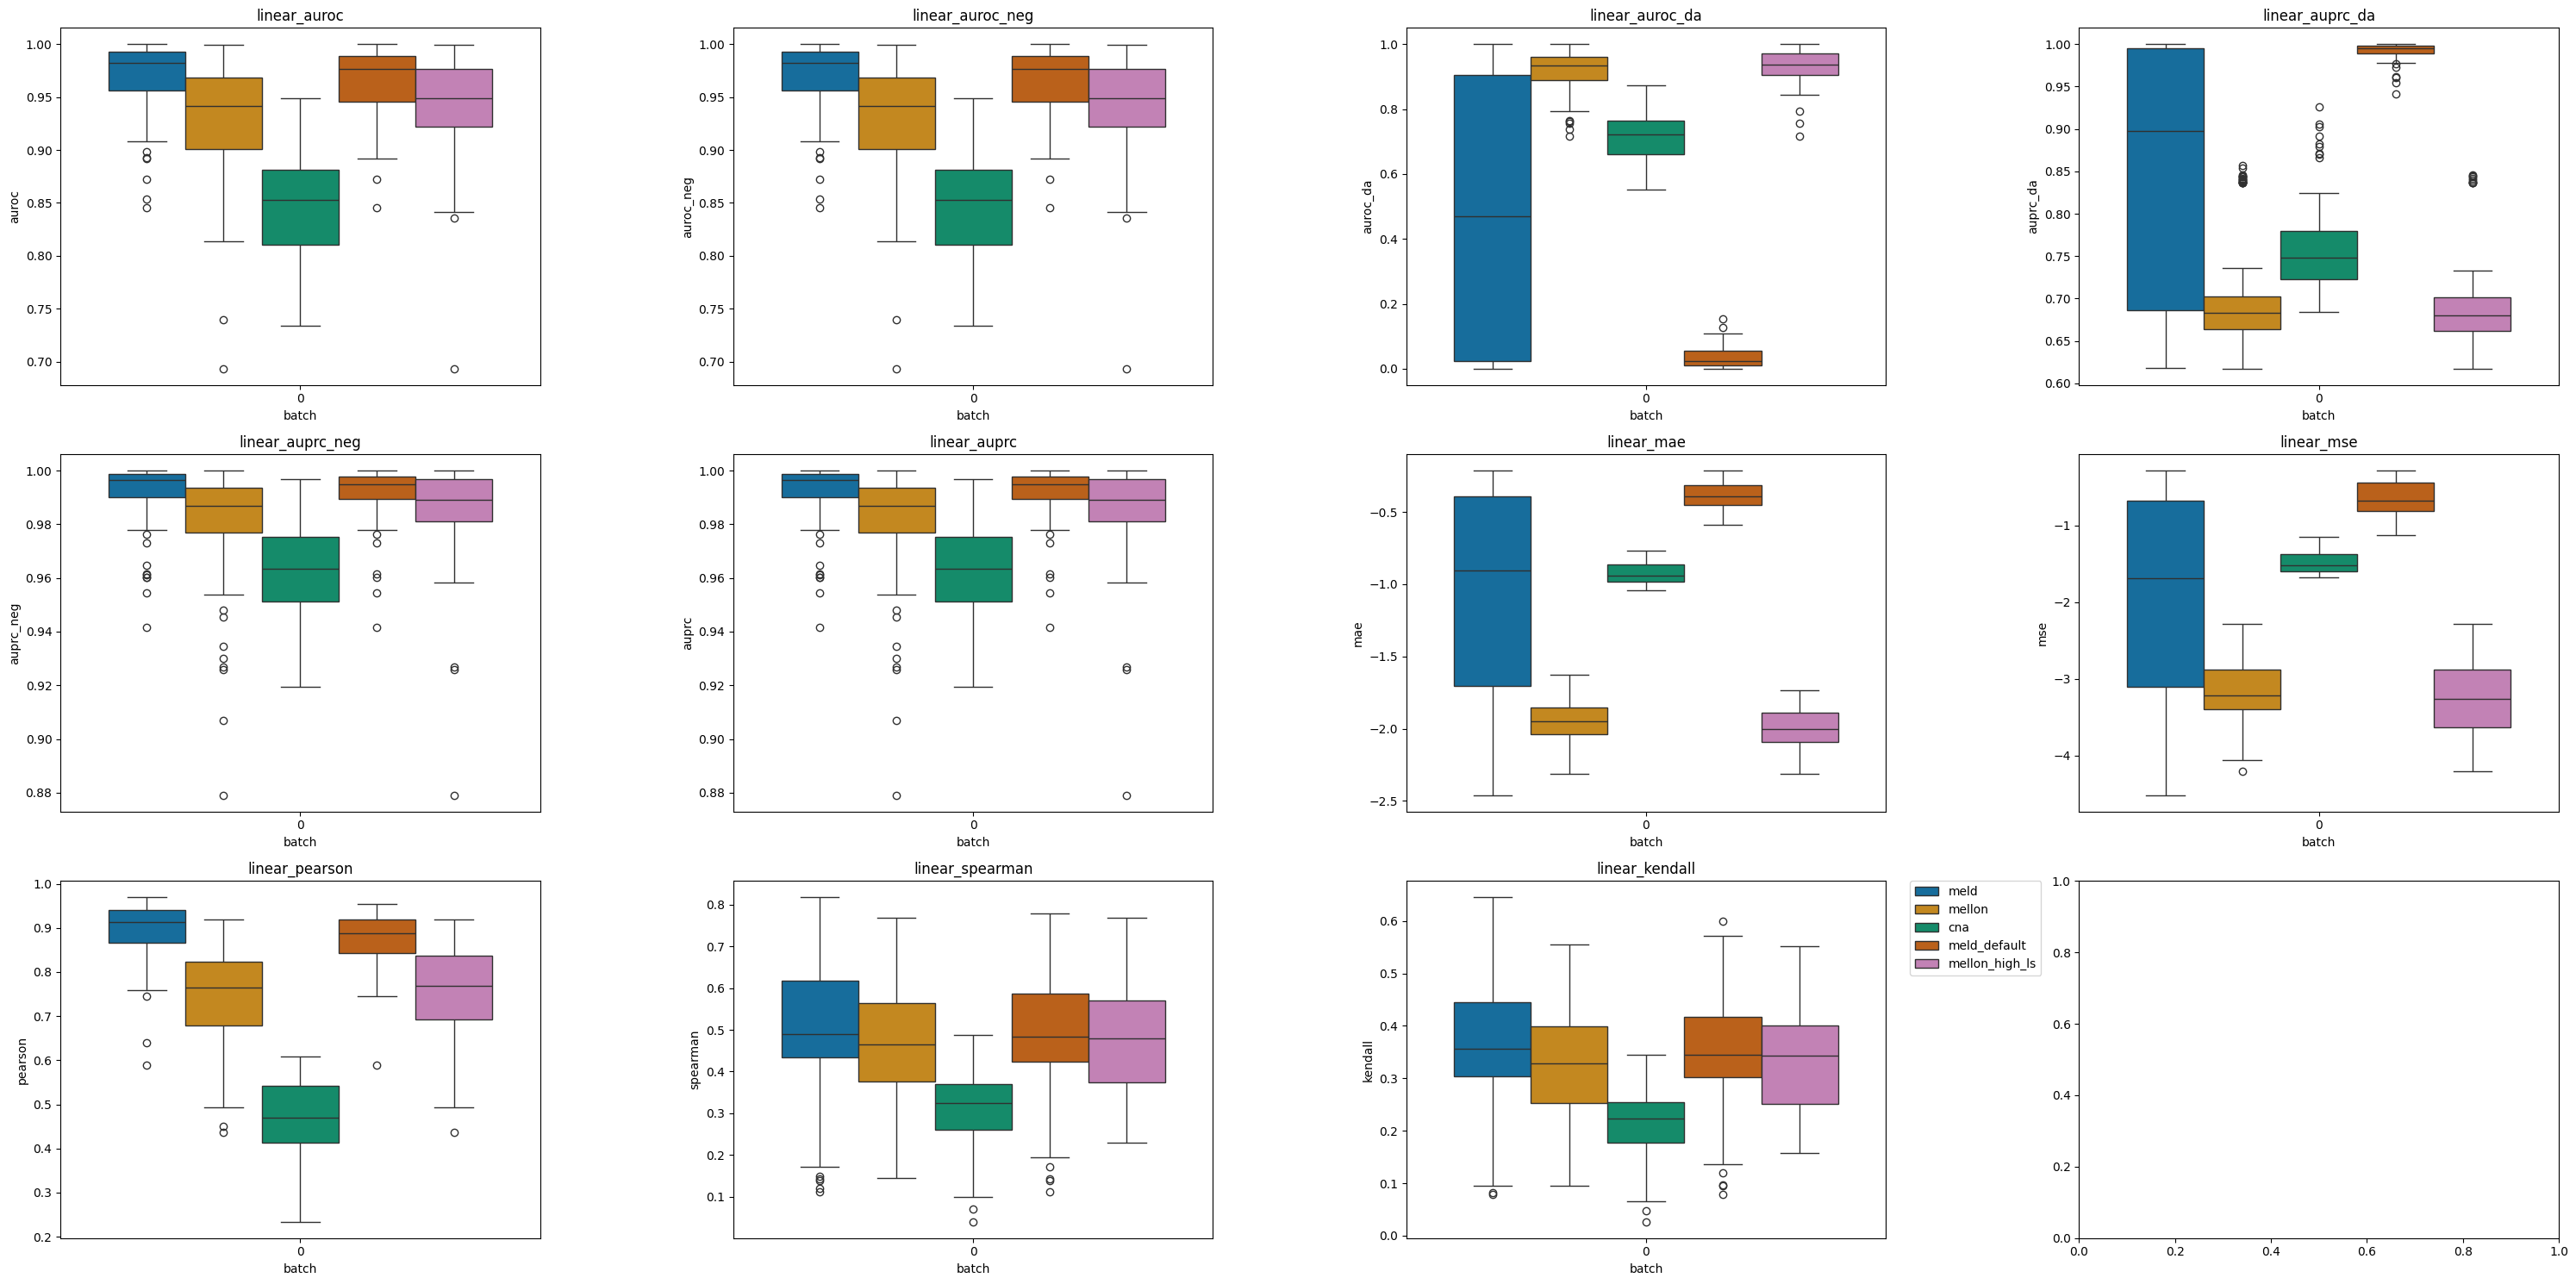

In [150]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

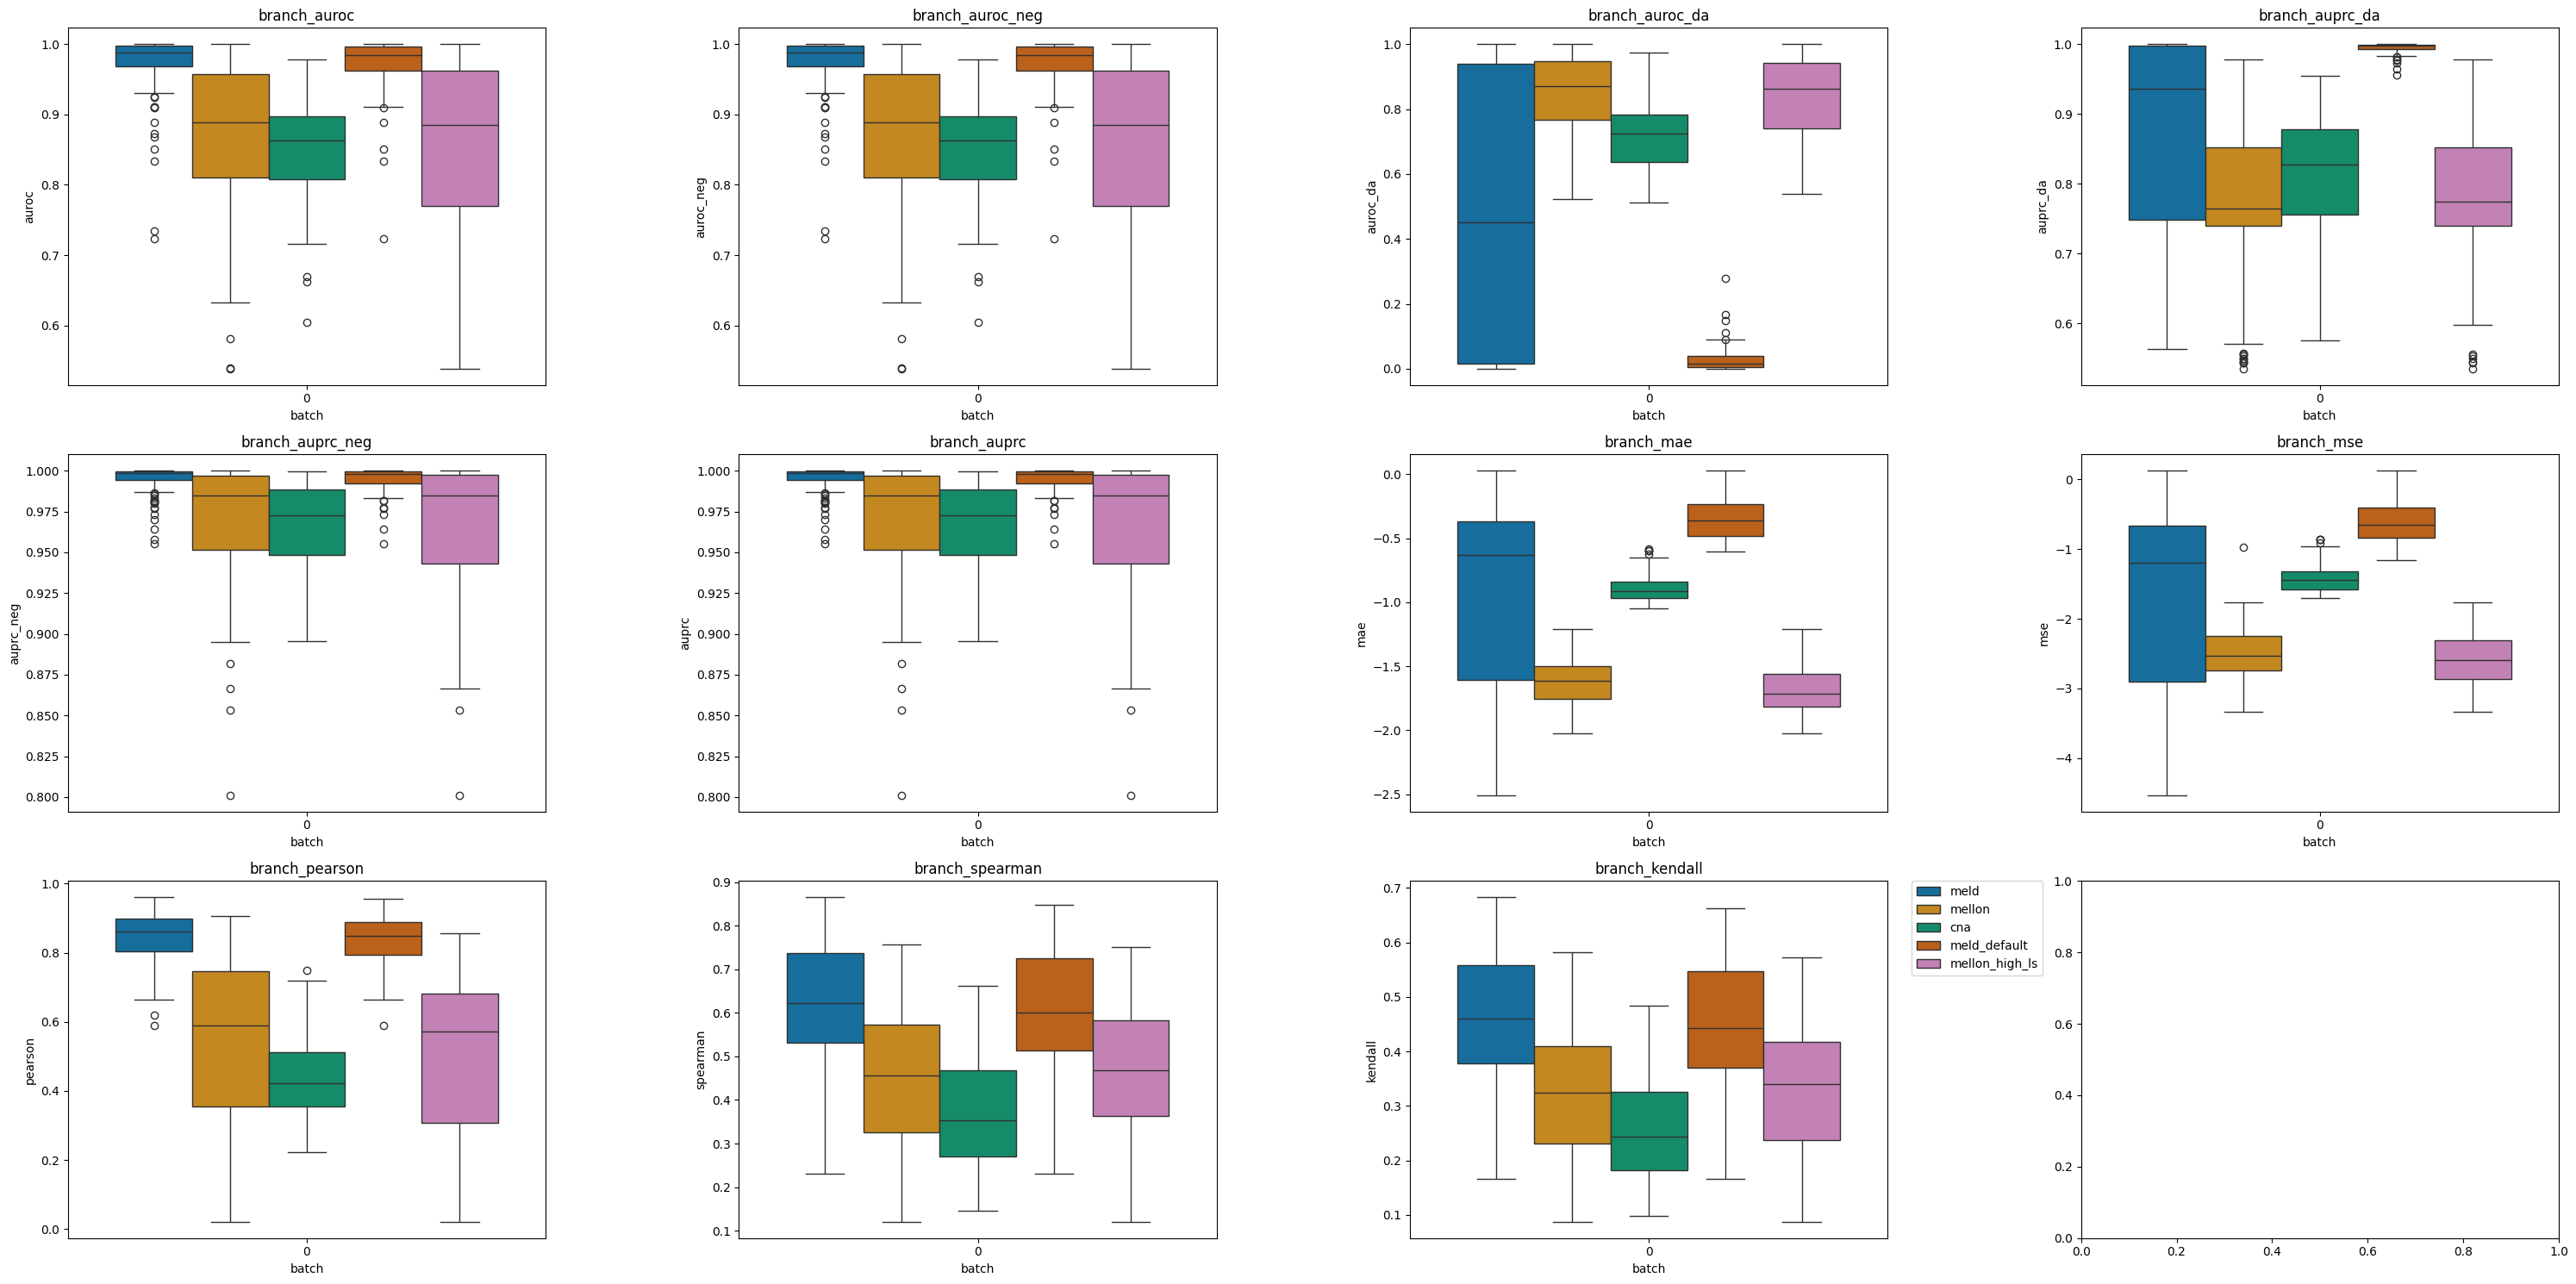

In [151]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x = general_performance_df['batch'],
/loc/scratch/11397987/ipykernel_5552/812487969.py:119: UserWarning: The palette list has more values (9) than needed (5), which may not be intended.
  plot = sns.boxplot(x 

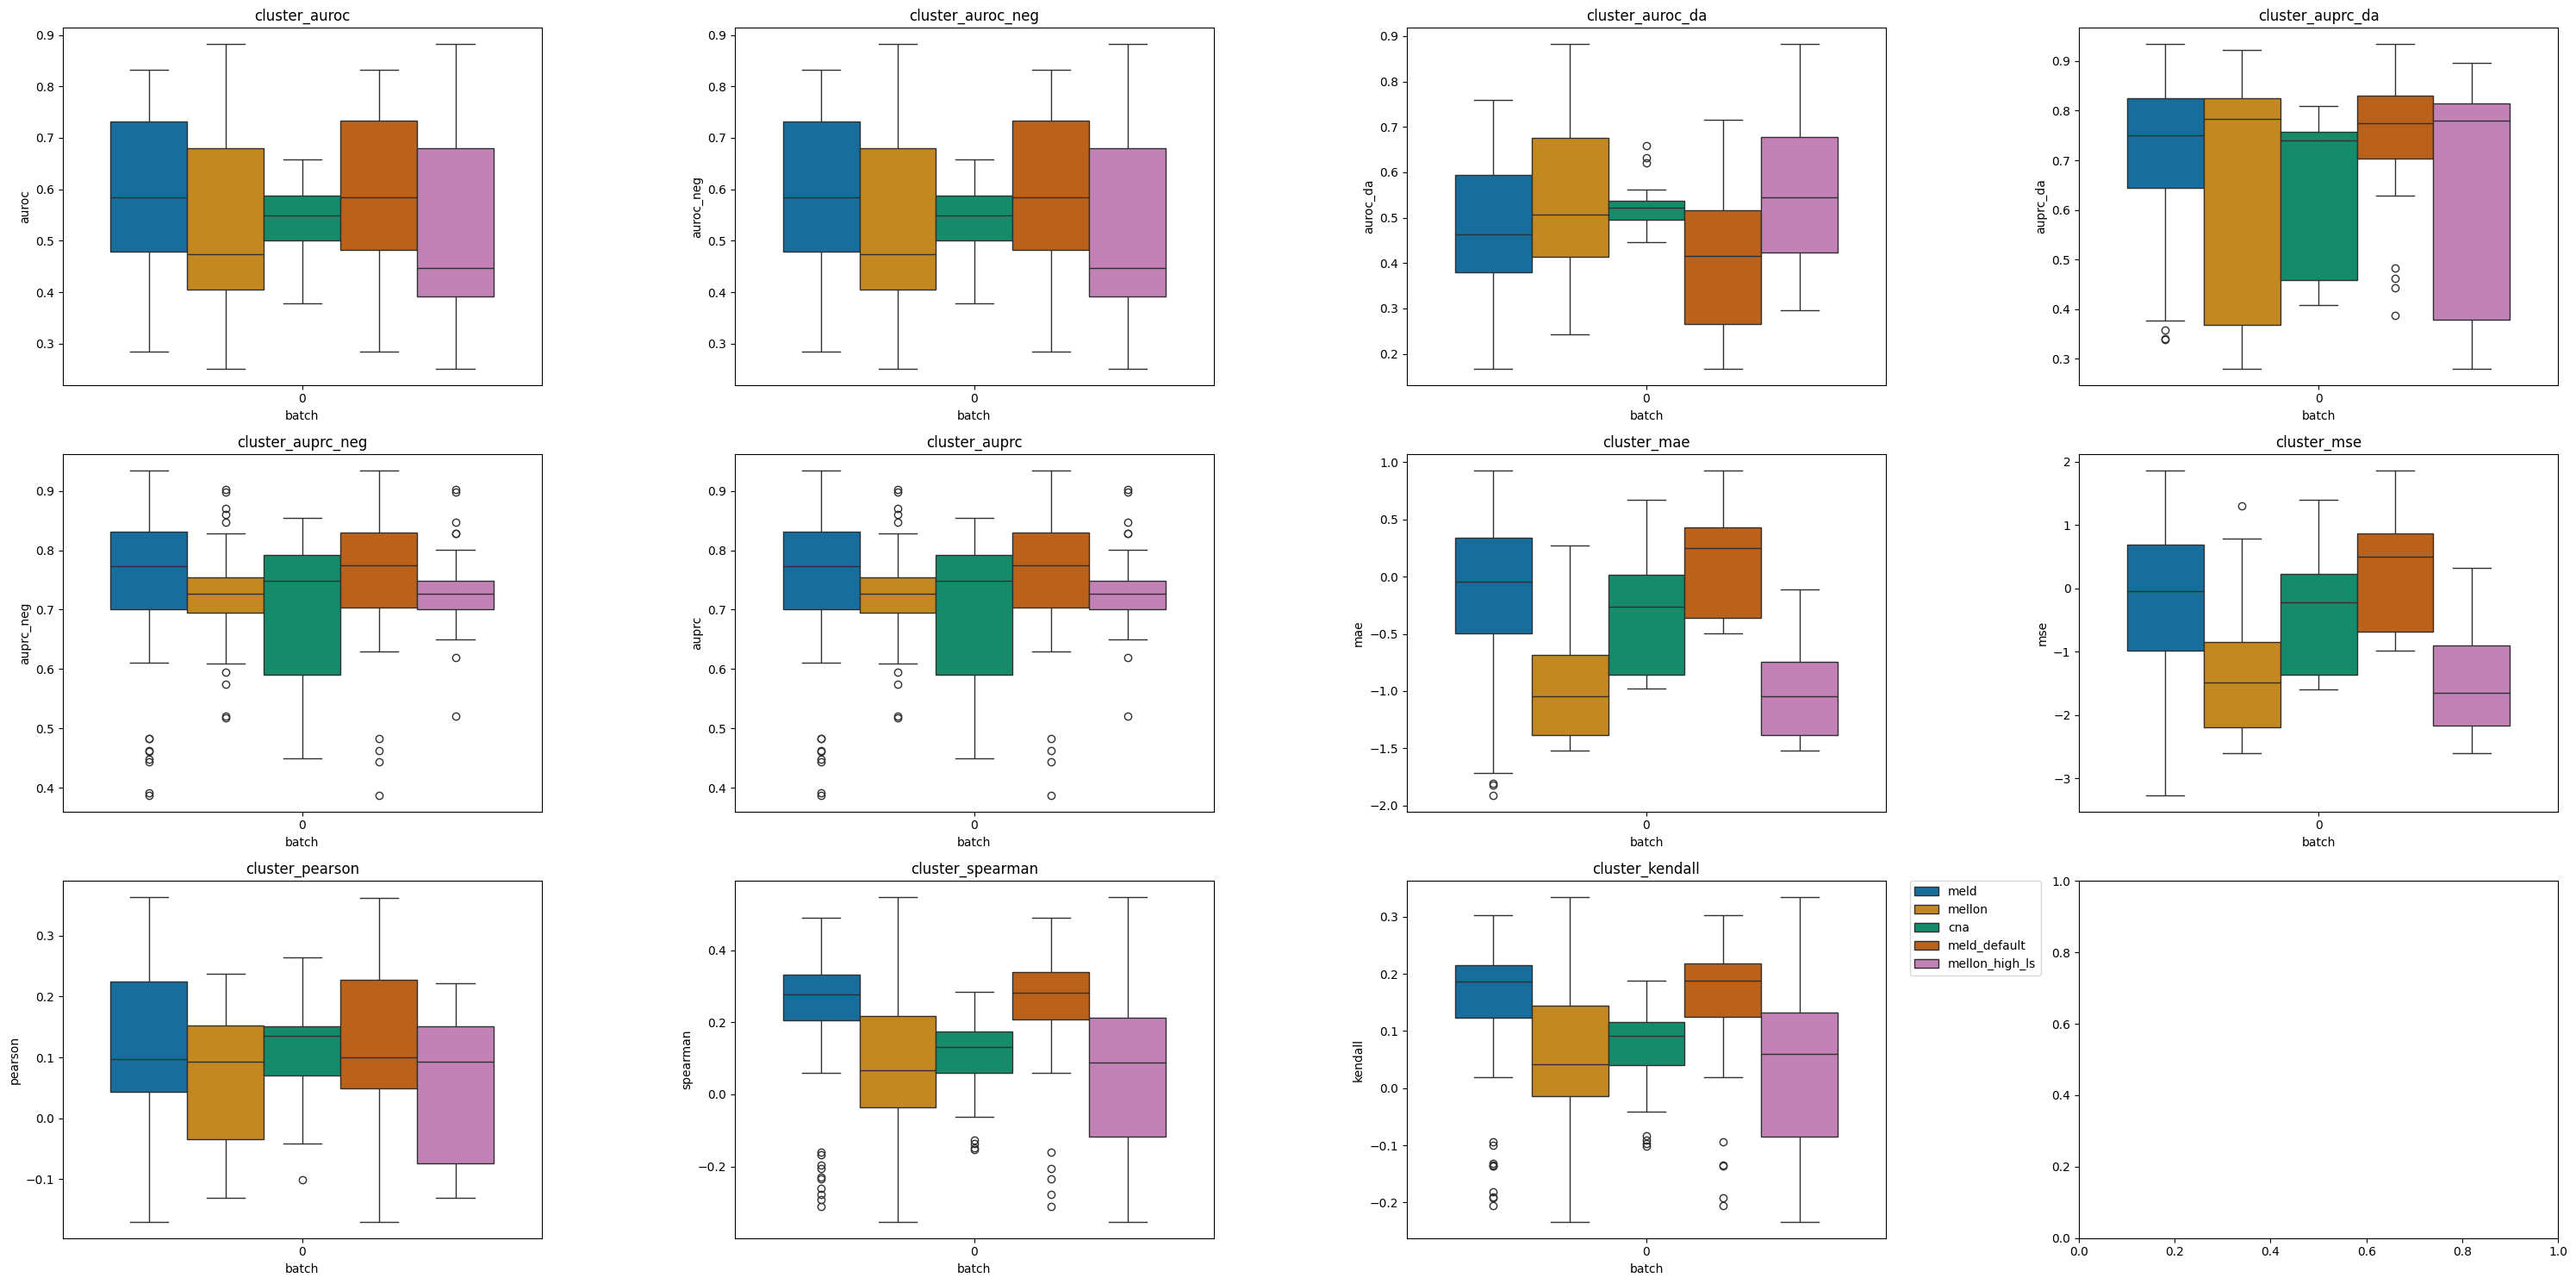

In [152]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

for i in range(len(metrics)):
    get_performance_batch("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()